Import necessary libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Upload all datasets.

In [ ]:
dataset_phishing = pd.read_csv('/content/dataset_phishing.csv')
web_page_phishing = pd.read_csv('/content/web-page-phishing.csv')
Phishing_Email = pd.read_csv('/content/Phishing_Email.csv')


Calculate class balance for each of the datasets.

In [ ]:
dataset_phishing['status'].value_counts()

,count
status,
legitimate,5715
phishing,5715


In [ ]:
web_page_phishing['phishing'].value_counts()

,count
phishing,
0,63715
1,36362


In [ ]:
Phishing_Email['Email Type'].value_counts()

,count
Email Type,
Safe Email,11322
Phishing Email,7312


It is clear that only the first dataset is well balanced while the other two have non-phishing URLs and emails respectively outnumbering phishing ones by a significantly large amount. Now, let's create bar graphs of the average values of each feature based on class for the first two datasets.

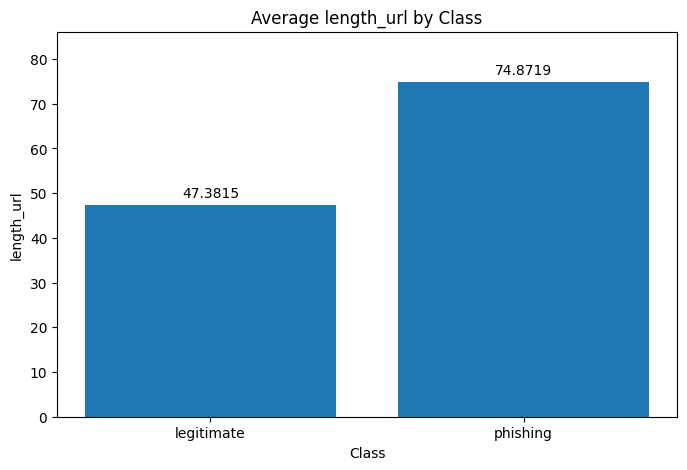

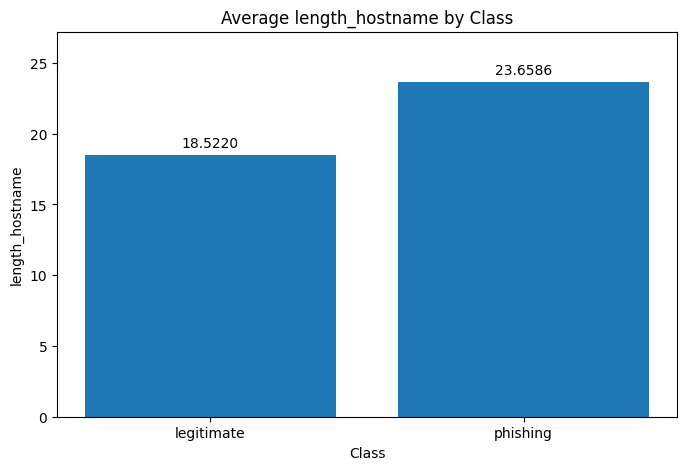

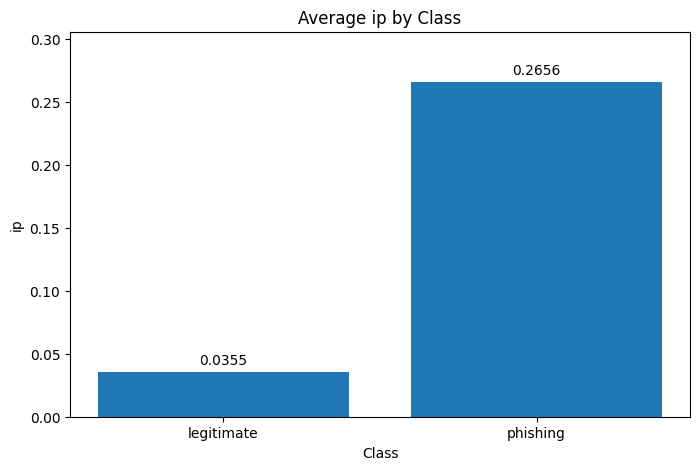

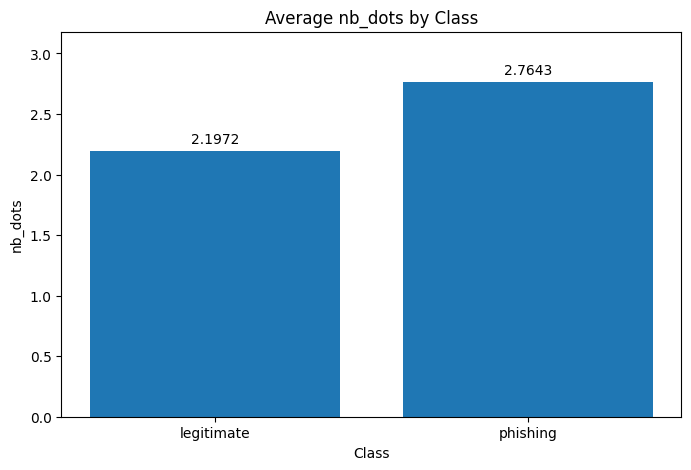

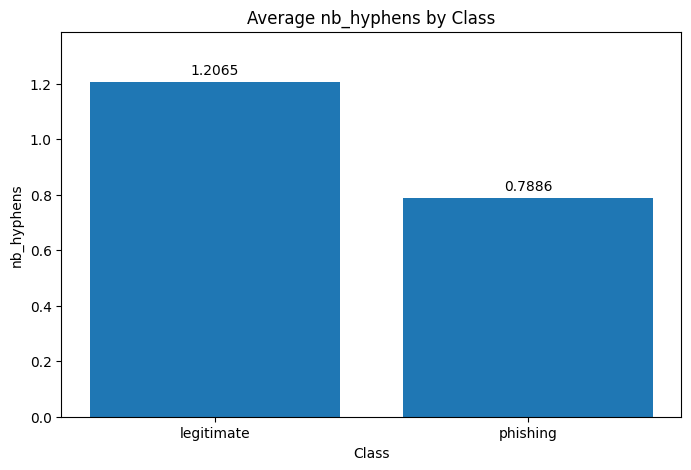

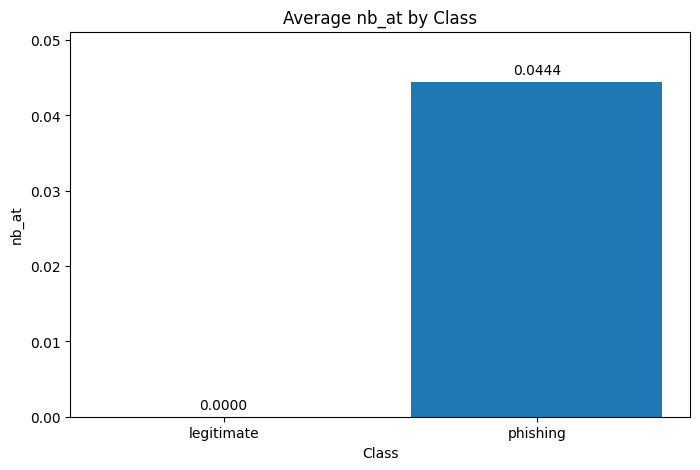

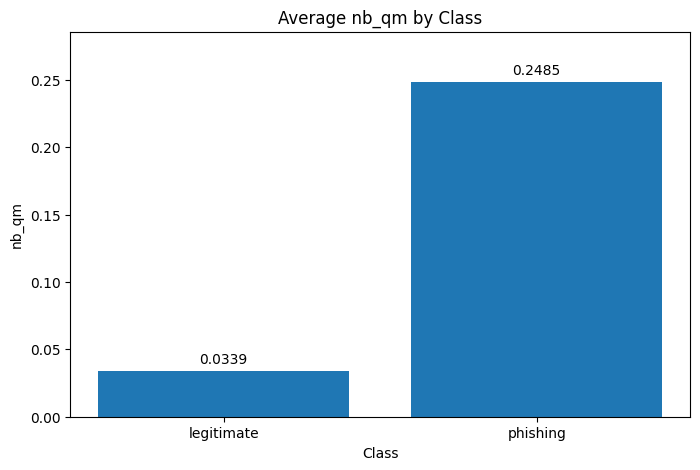

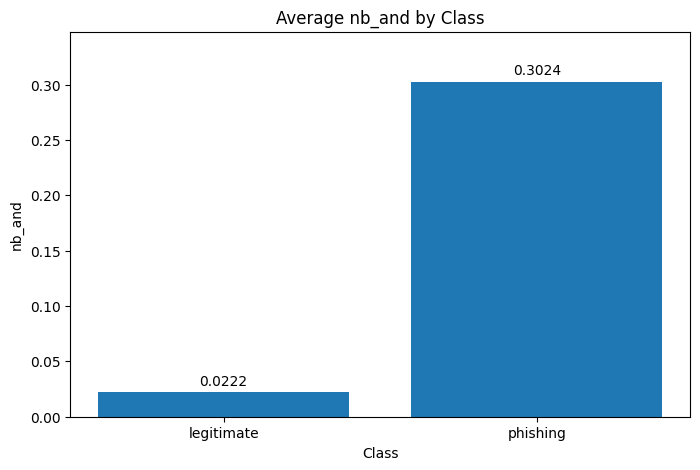

/tmp/ipython-input-3211135438.py:12: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, max(means.values) * 1.15)


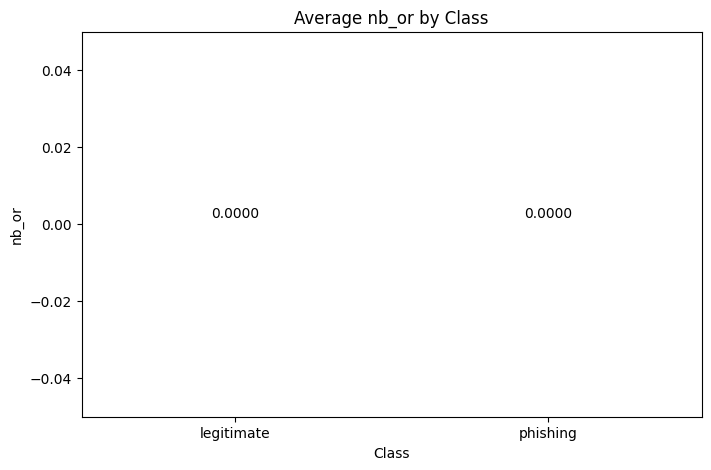

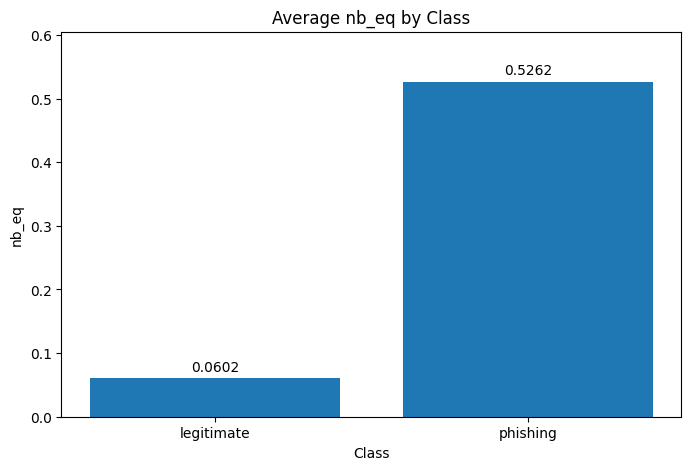

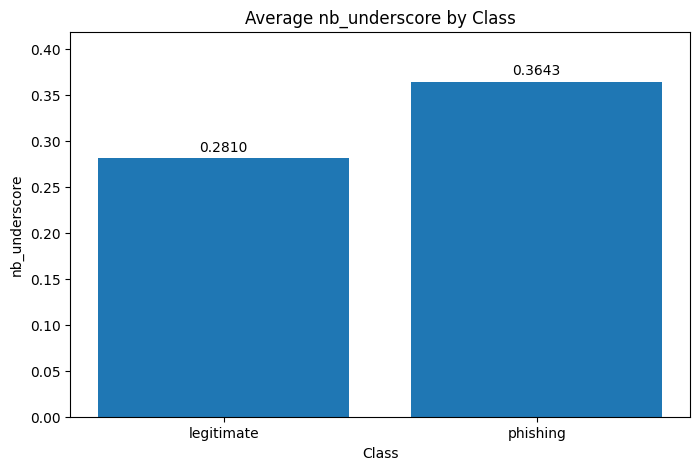

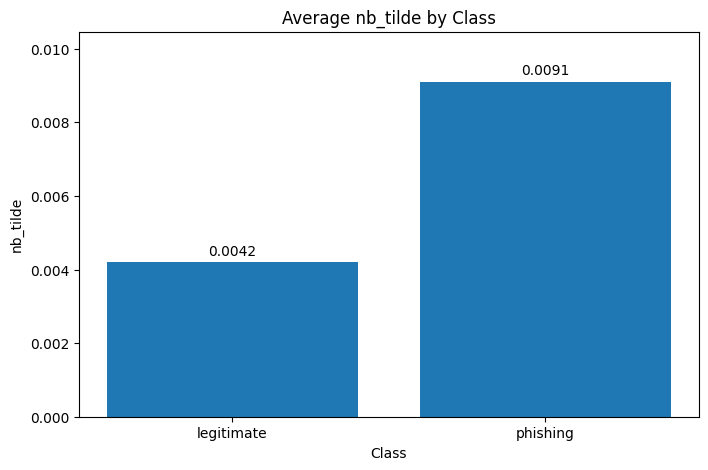

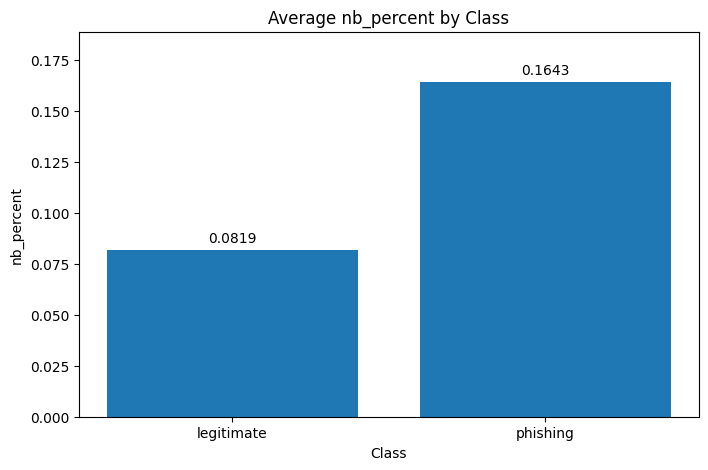

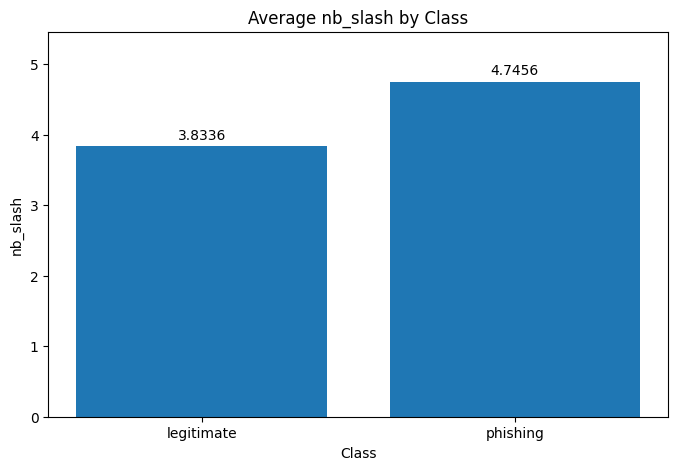

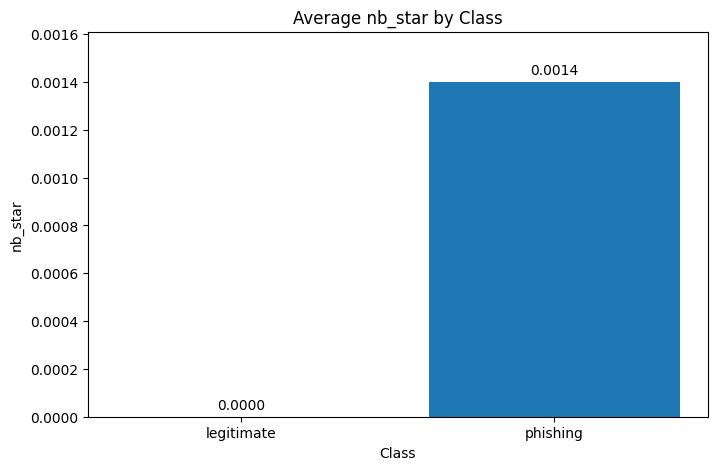

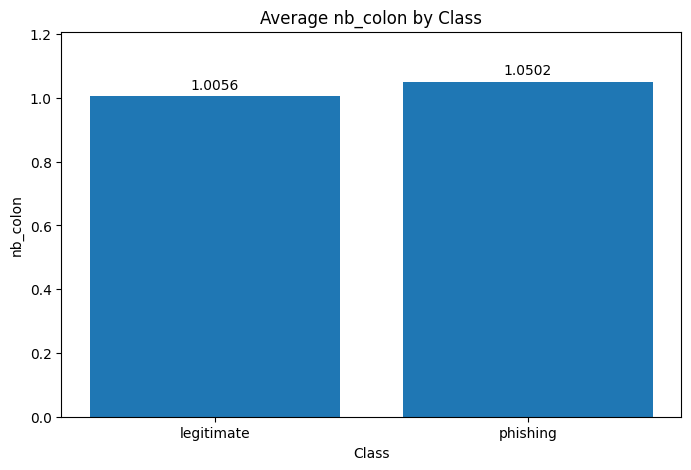

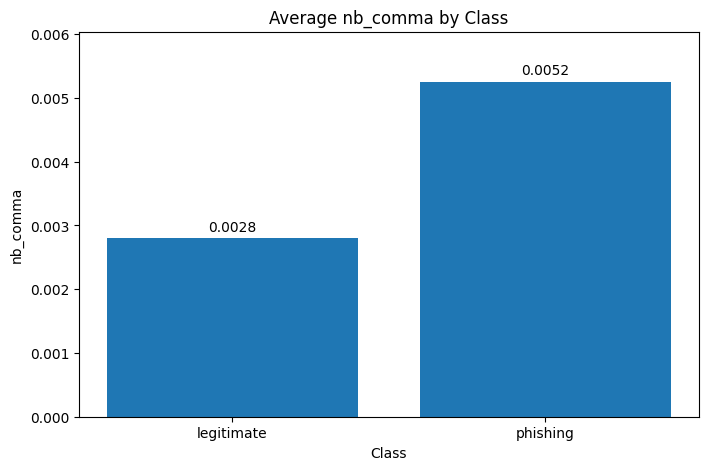

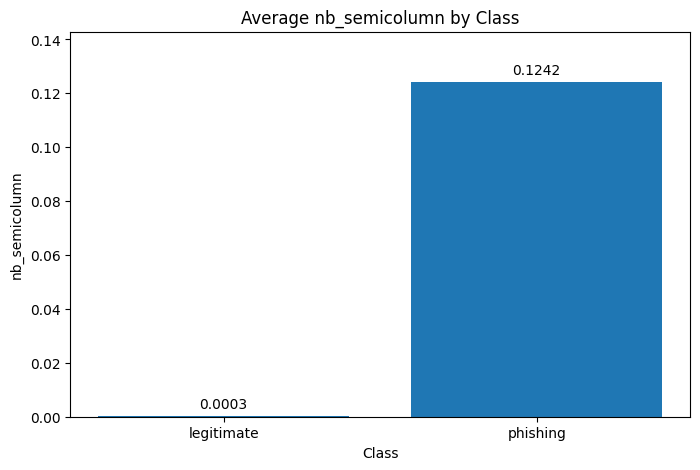

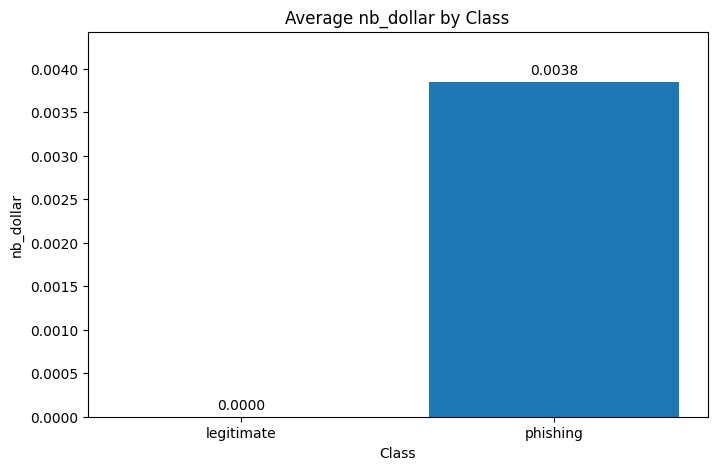

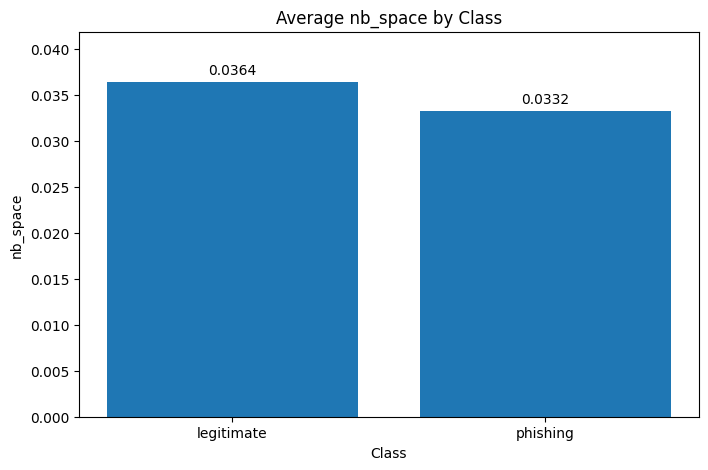

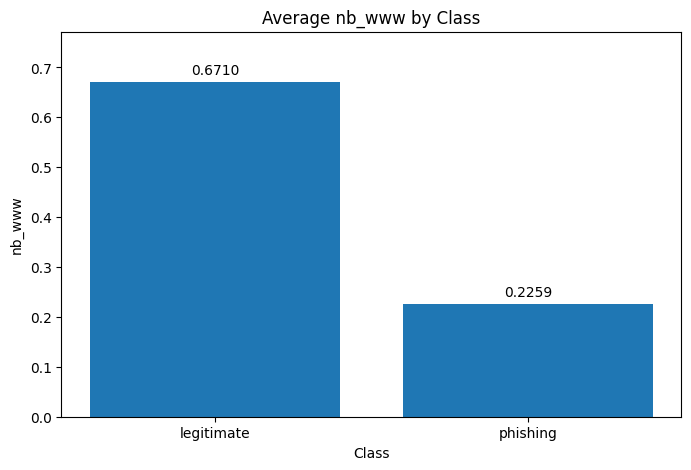

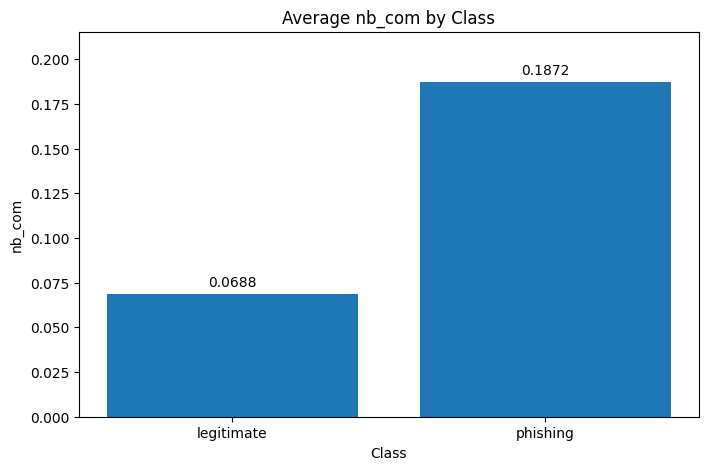

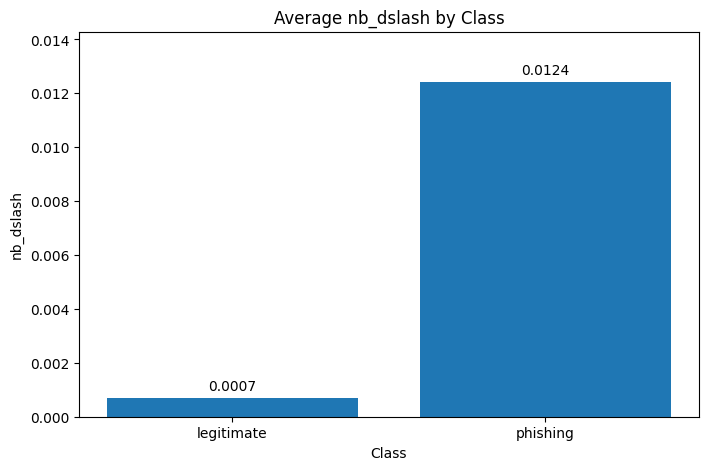

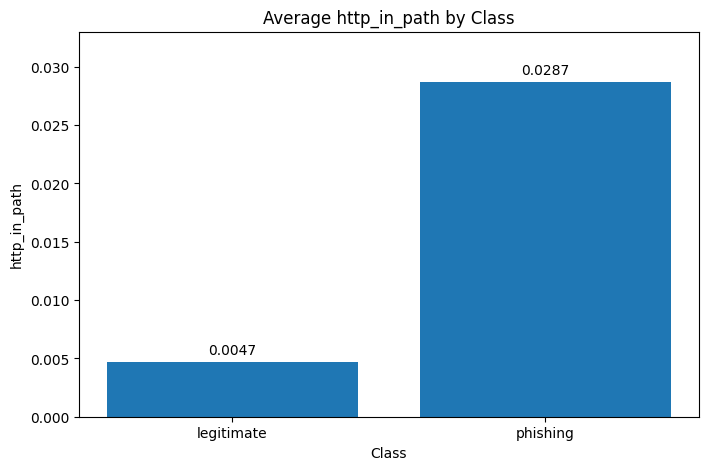

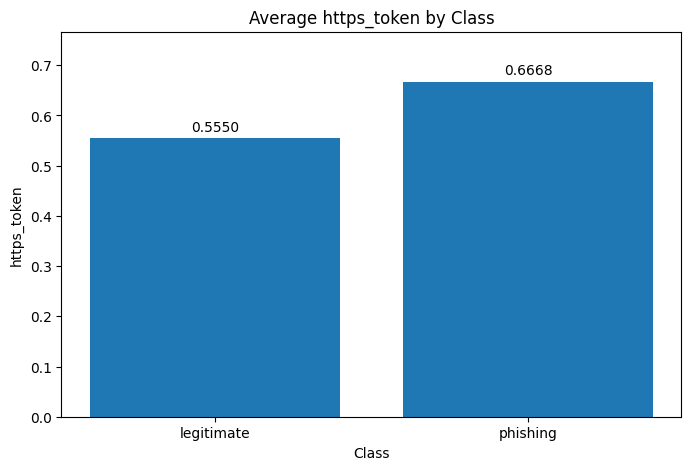

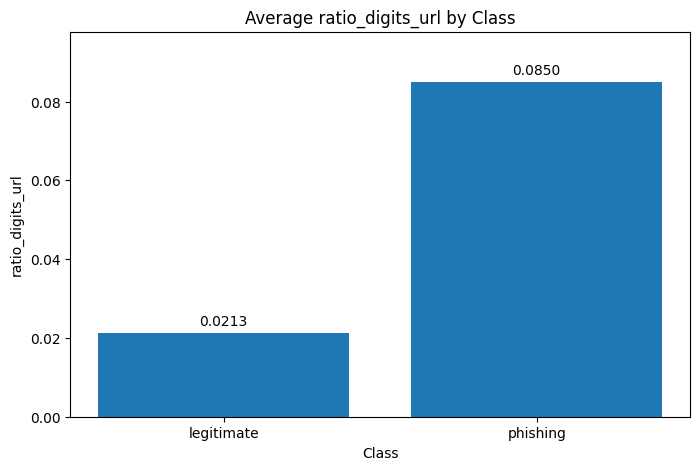

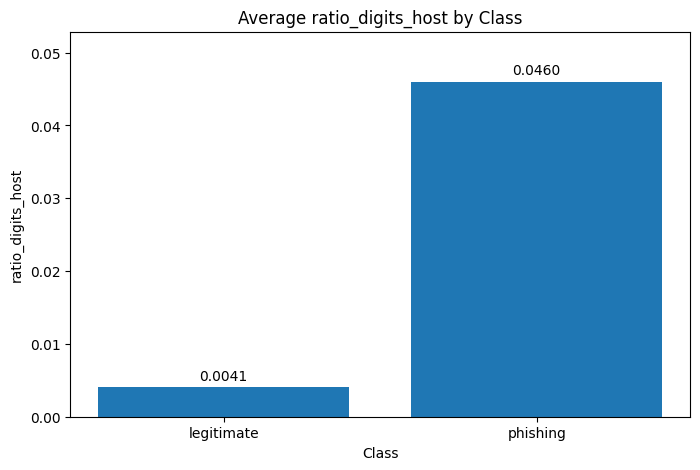

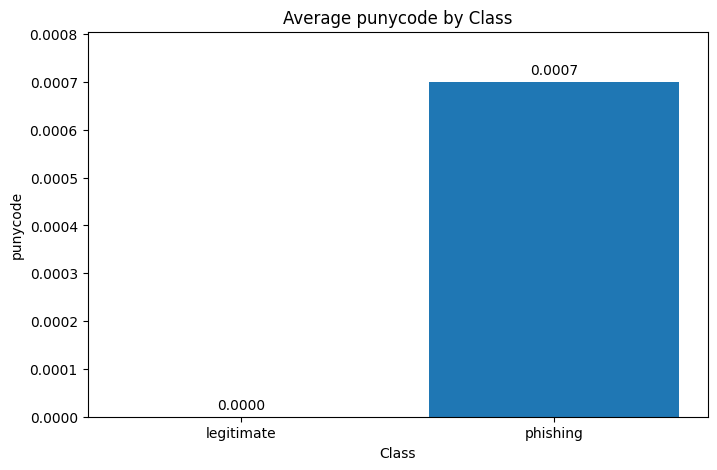

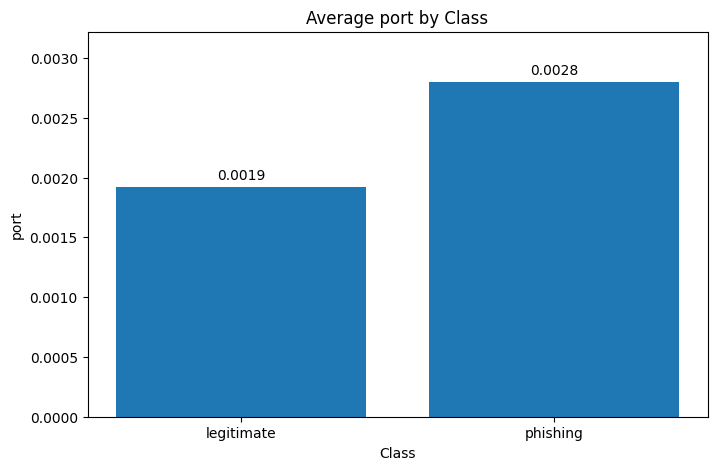

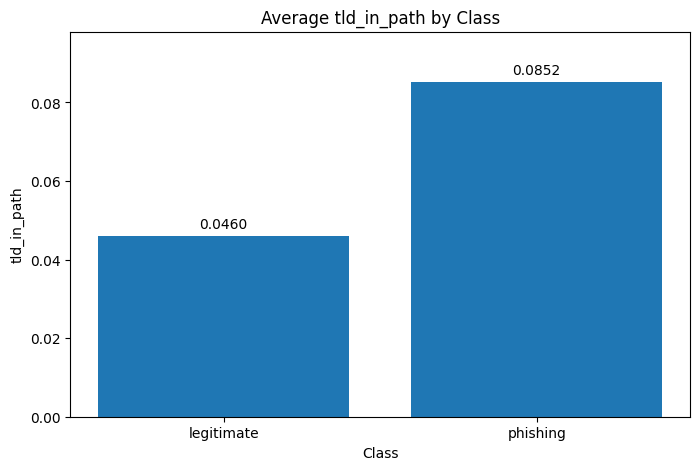

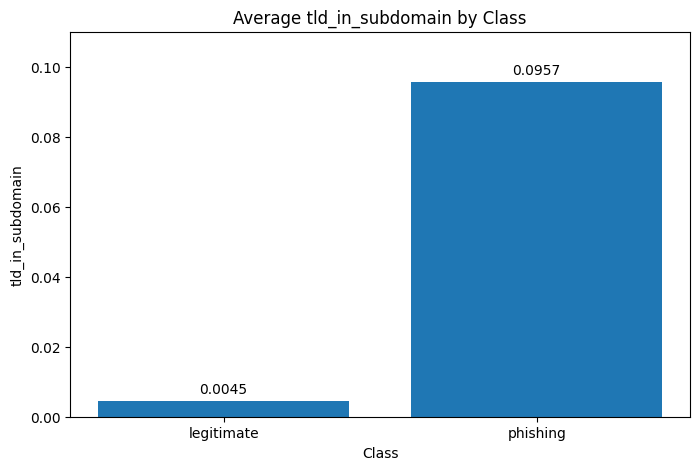

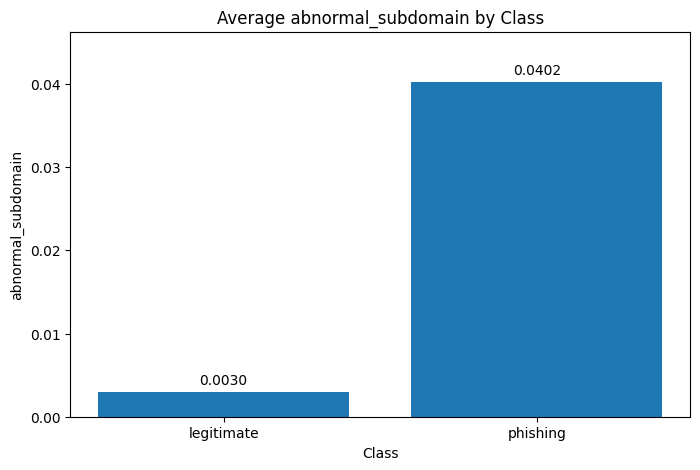

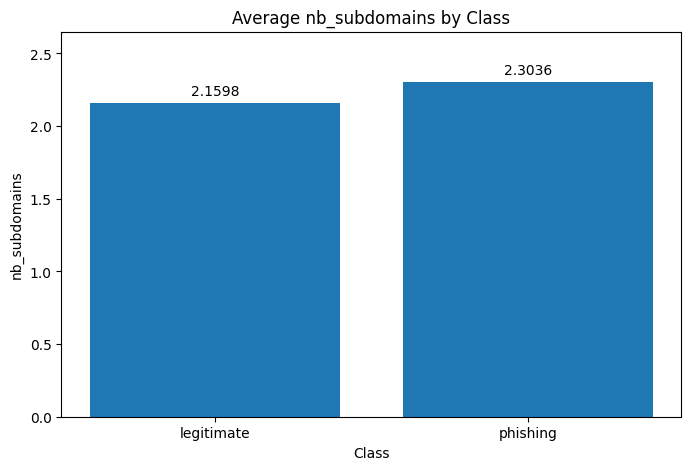

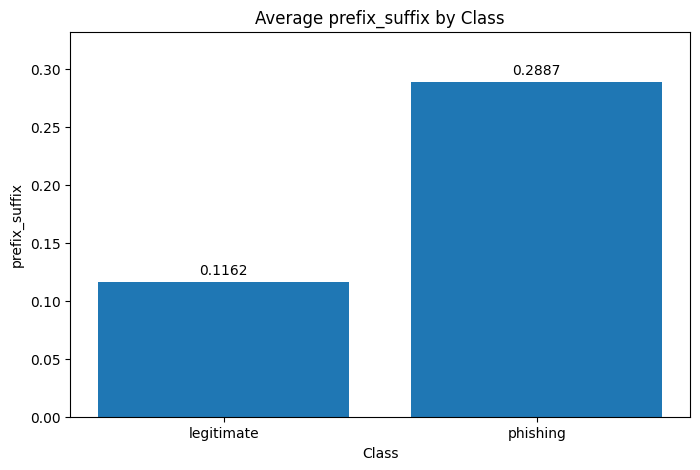

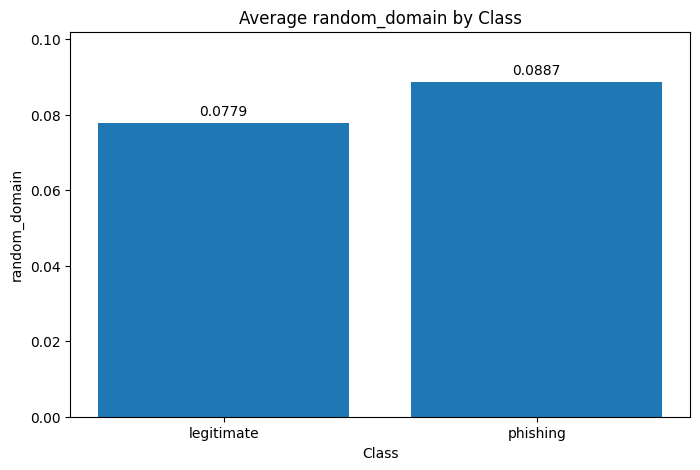

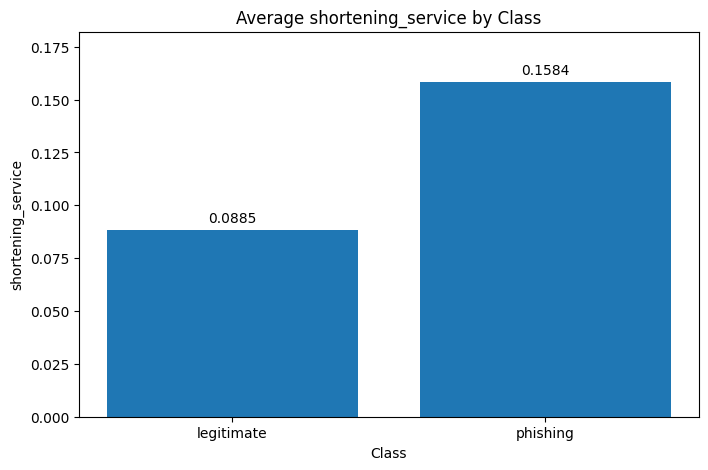

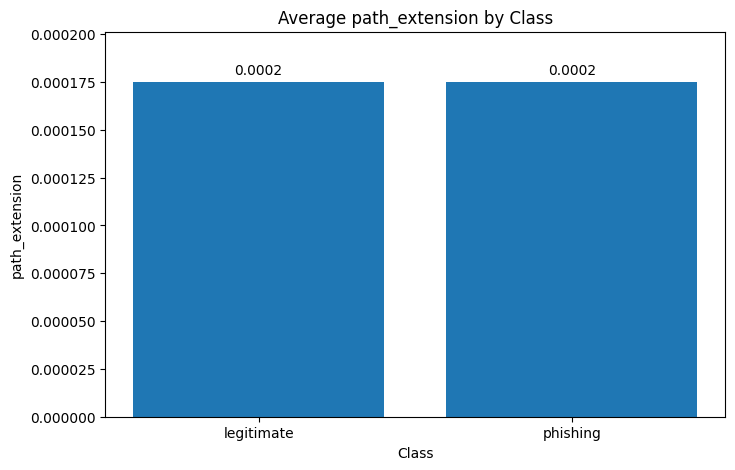

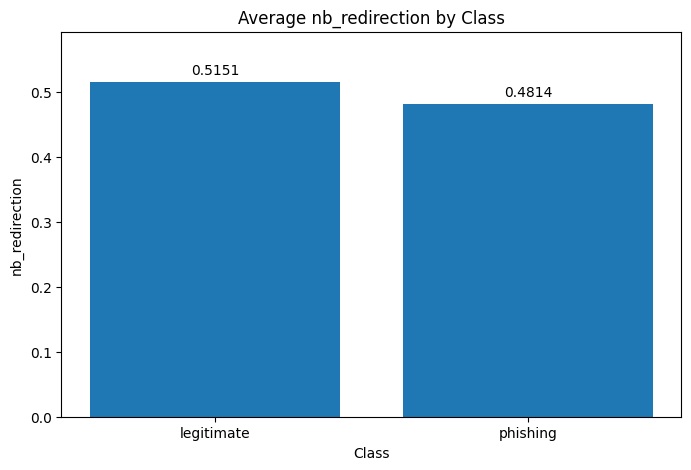

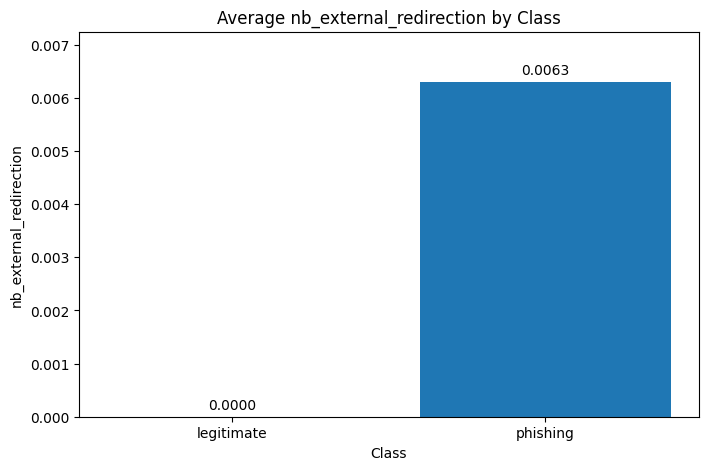

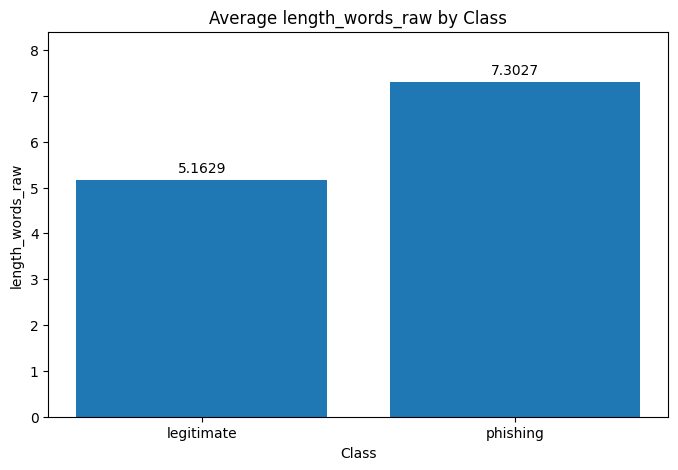

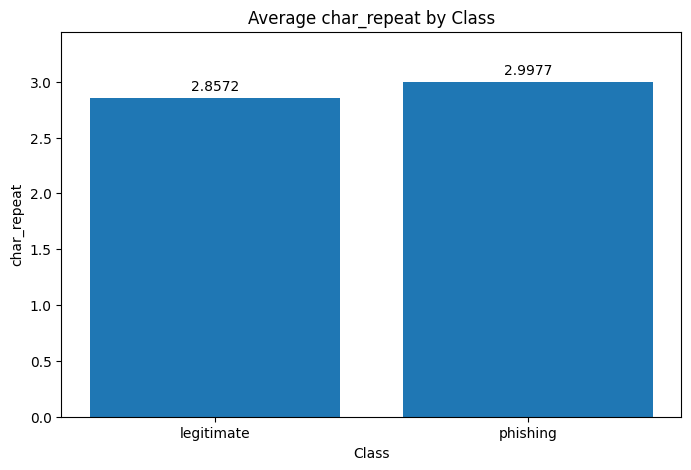

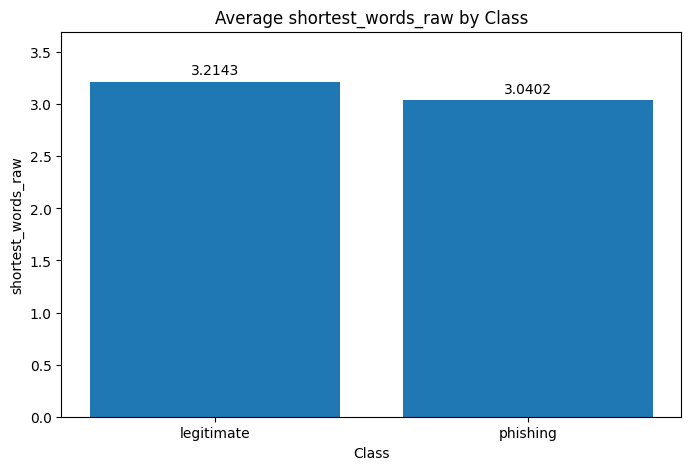

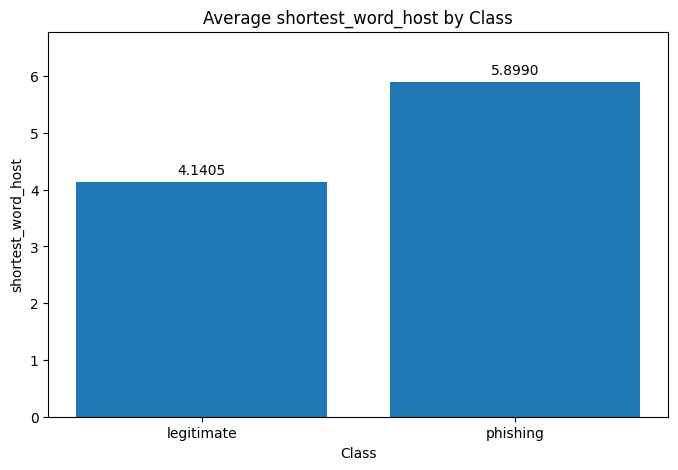

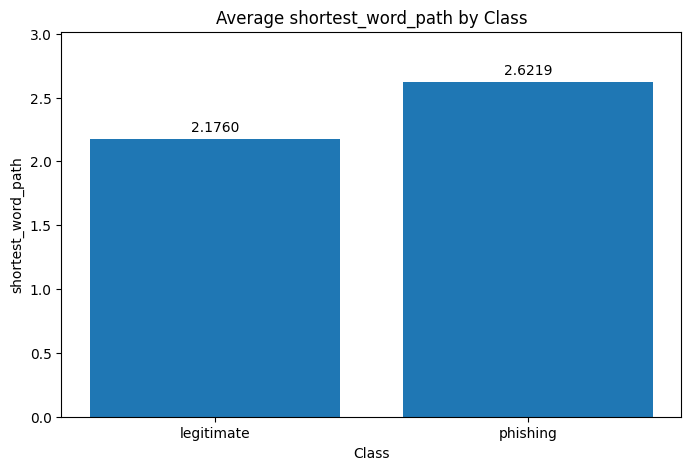

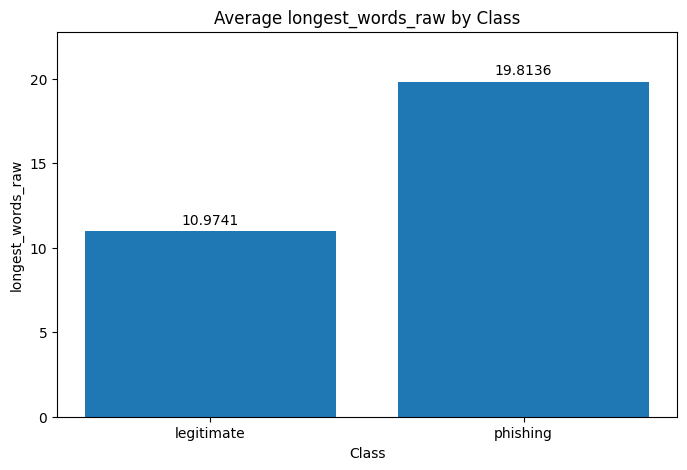

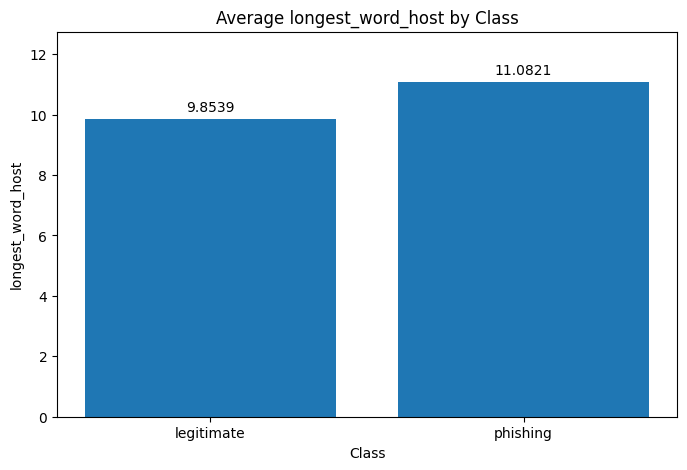

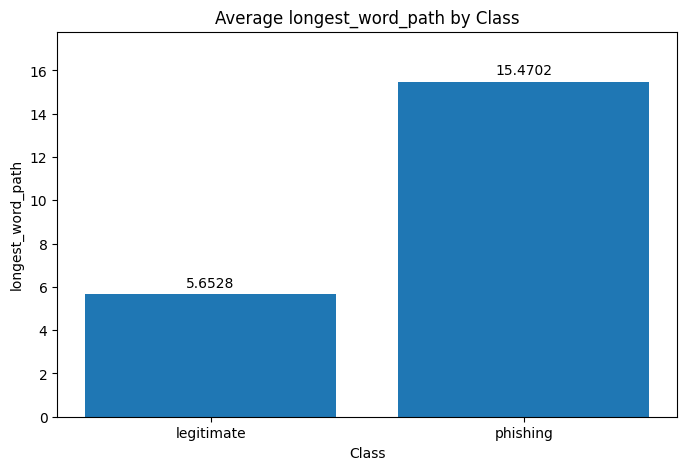

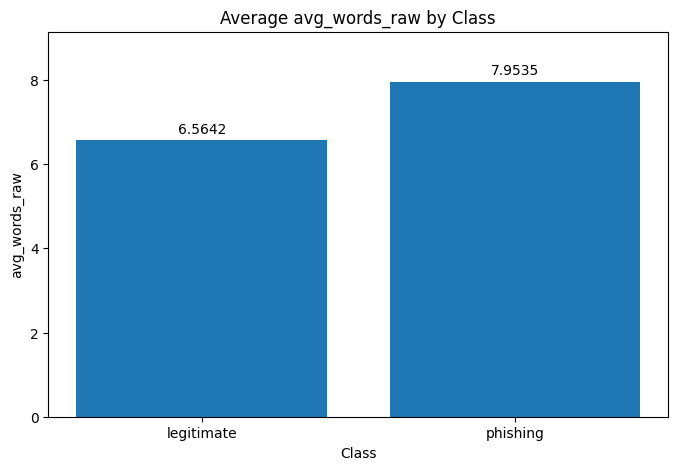

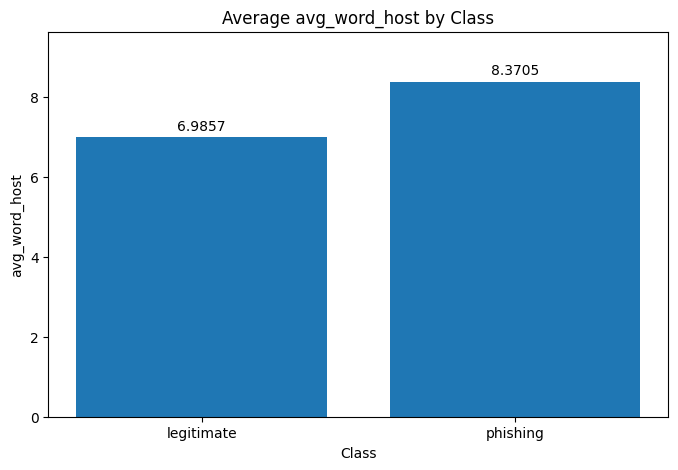

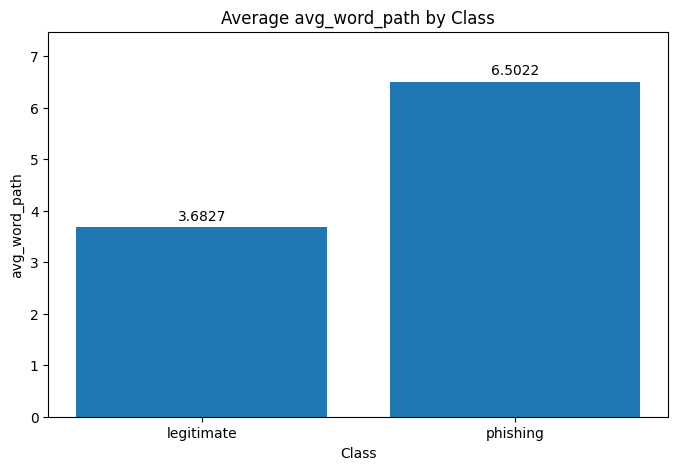

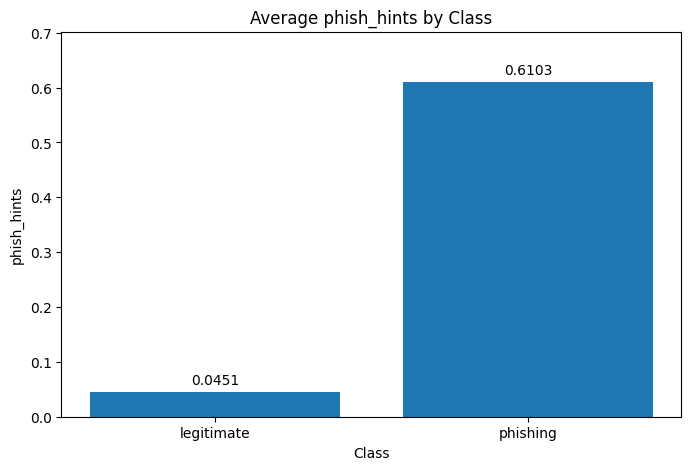

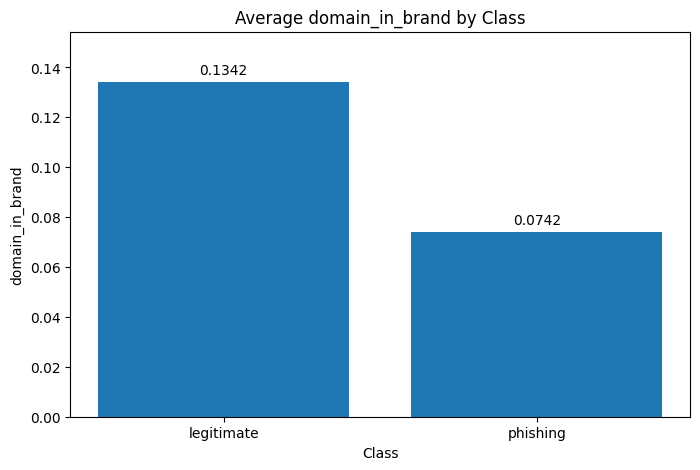

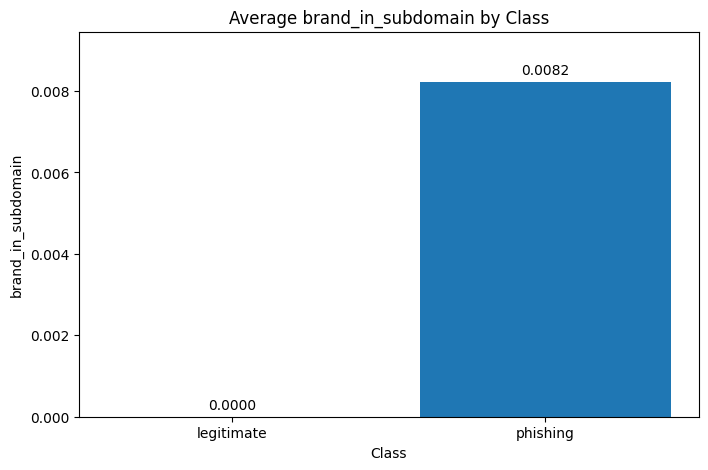

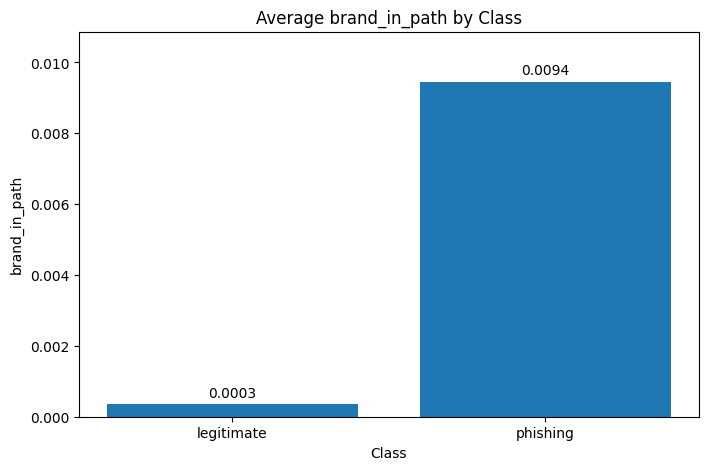

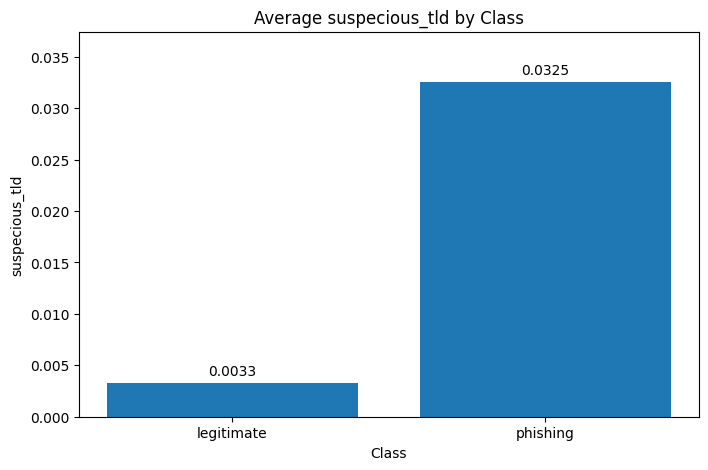

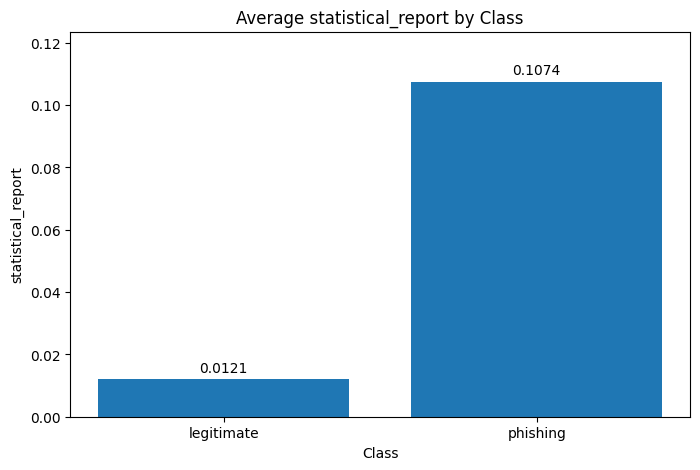

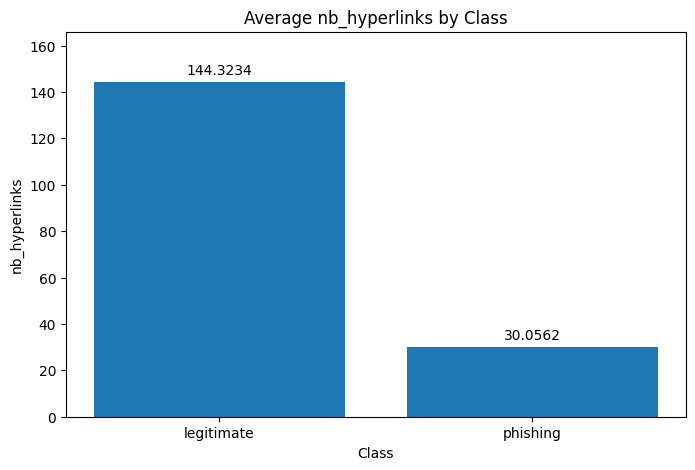

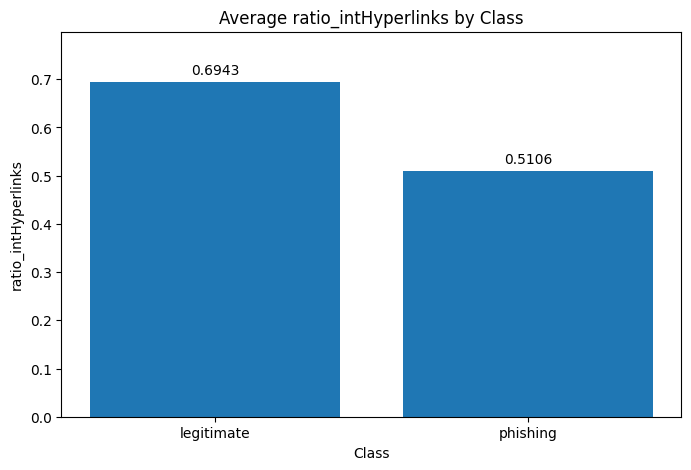

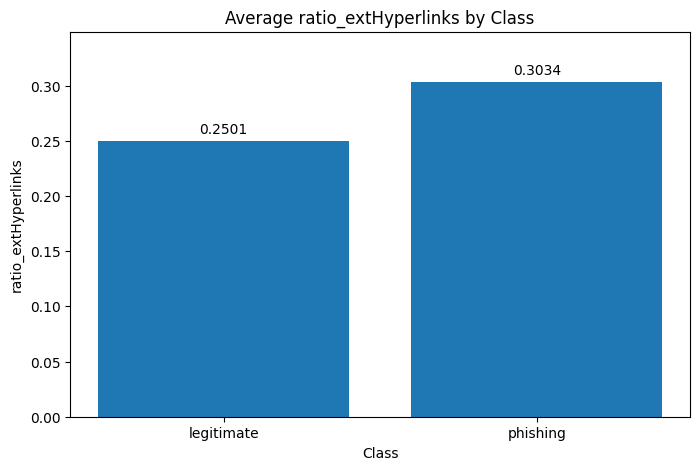

/tmp/ipython-input-3211135438.py:12: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, max(means.values) * 1.15)


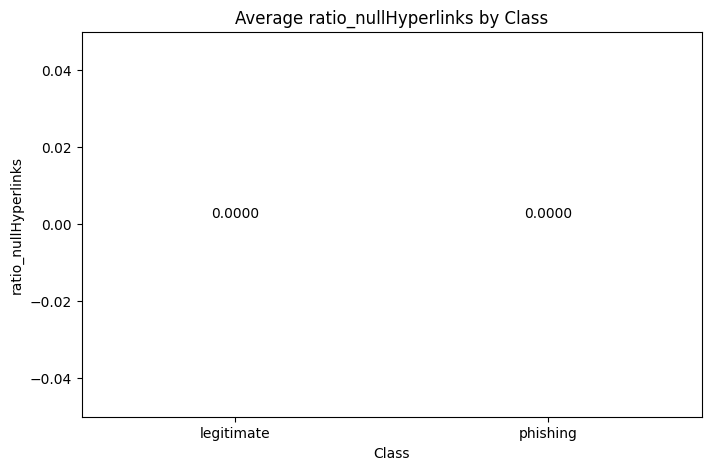

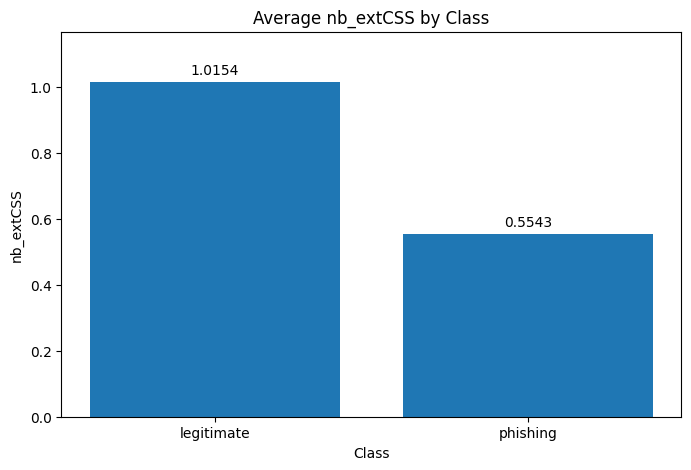

/tmp/ipython-input-3211135438.py:12: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, max(means.values) * 1.15)


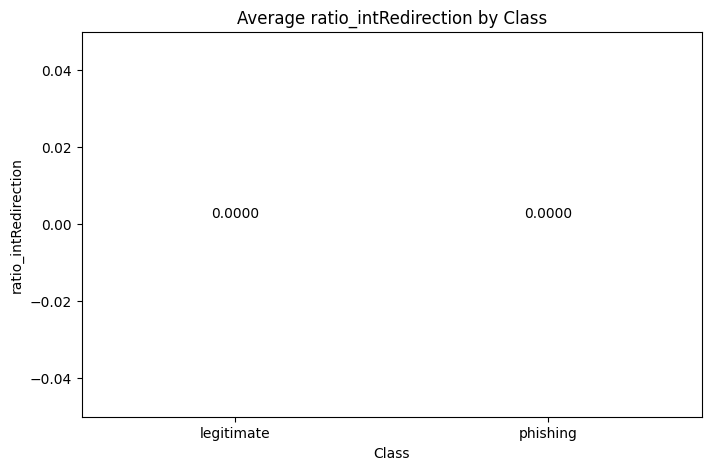

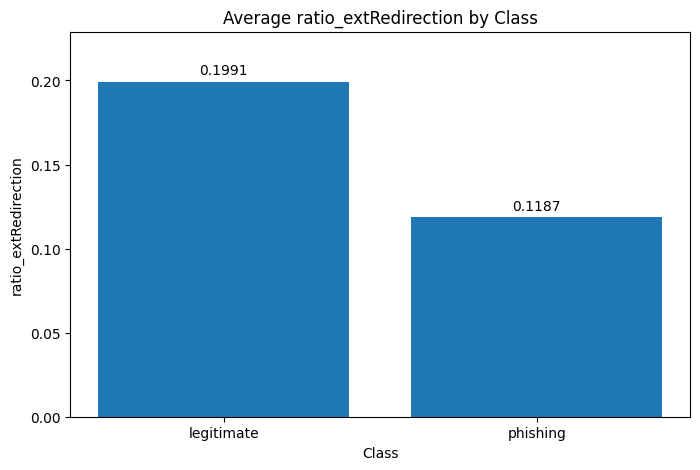

/tmp/ipython-input-3211135438.py:12: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, max(means.values) * 1.15)


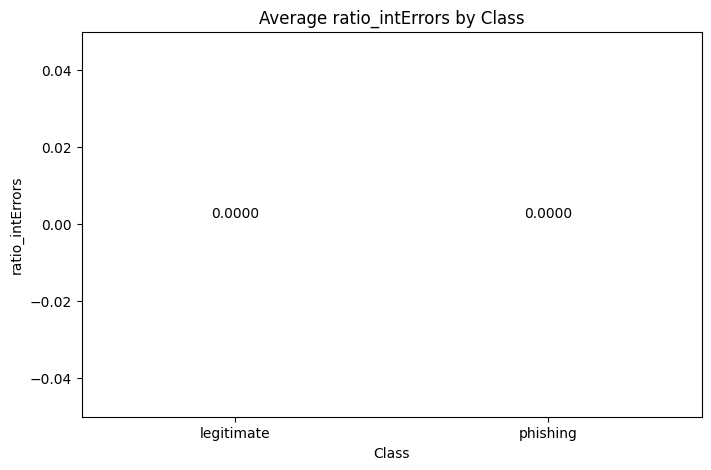

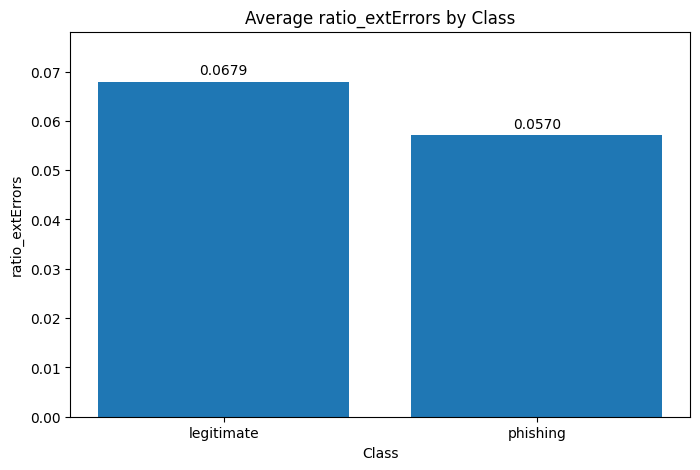

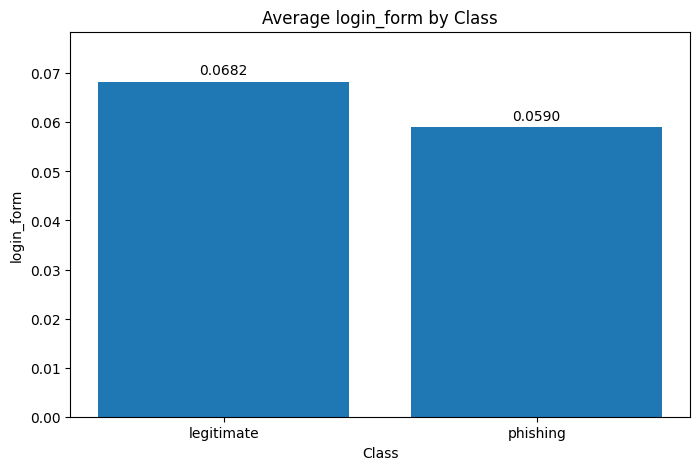

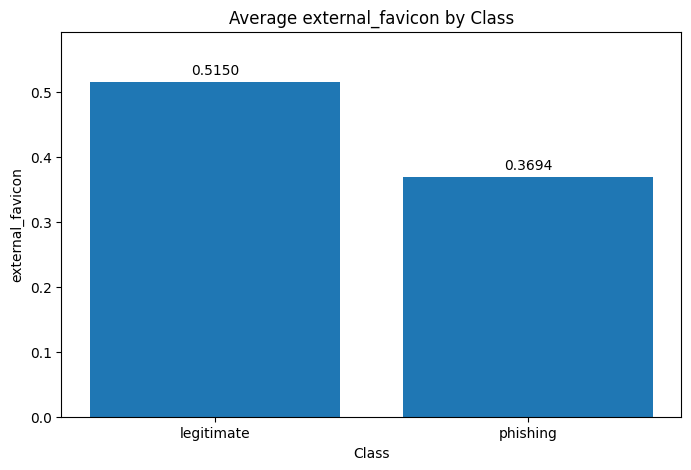

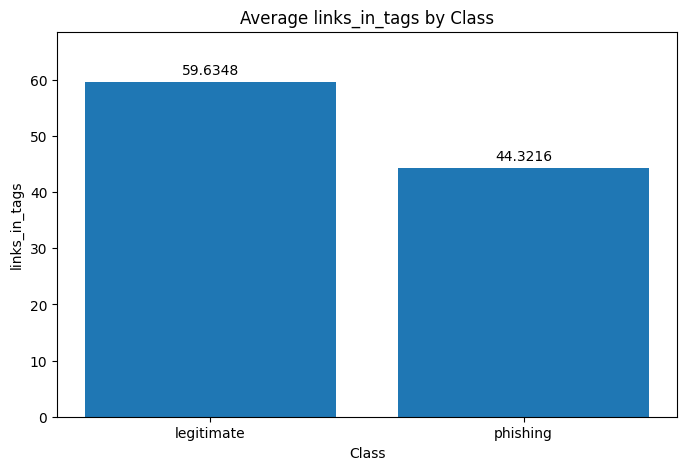

/tmp/ipython-input-3211135438.py:12: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, max(means.values) * 1.15)


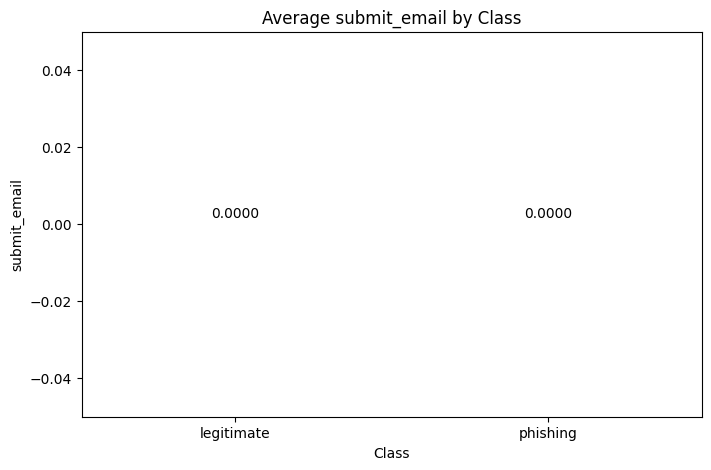

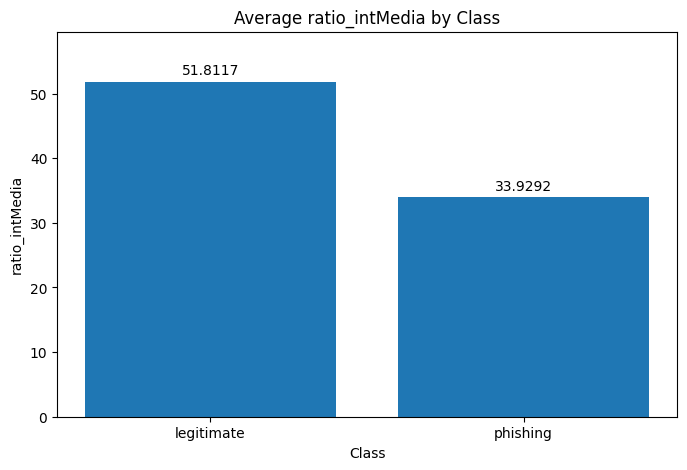

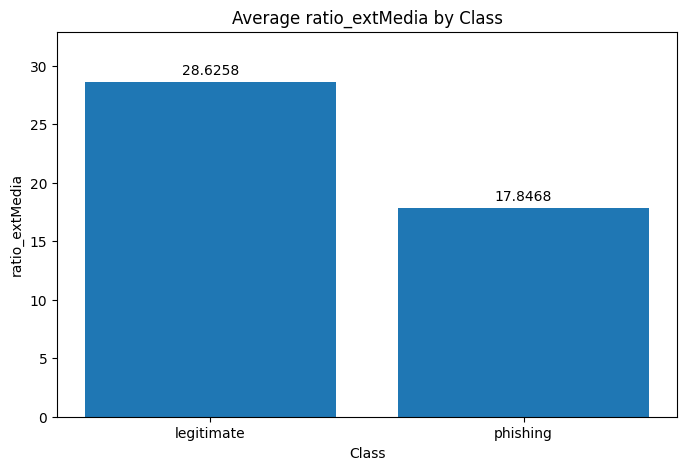

/tmp/ipython-input-3211135438.py:12: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, max(means.values) * 1.15)


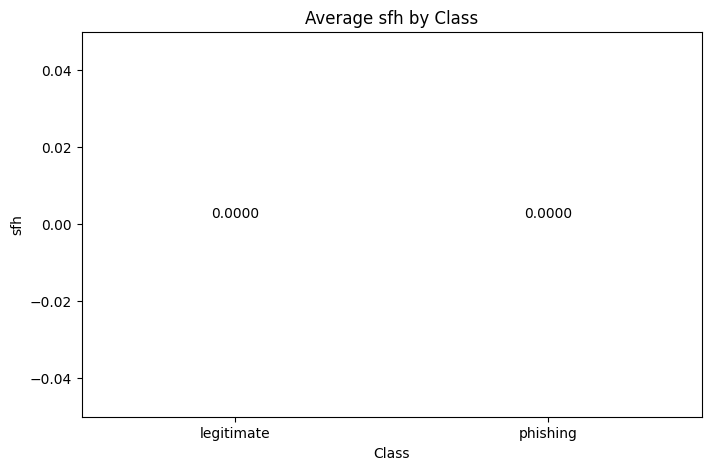

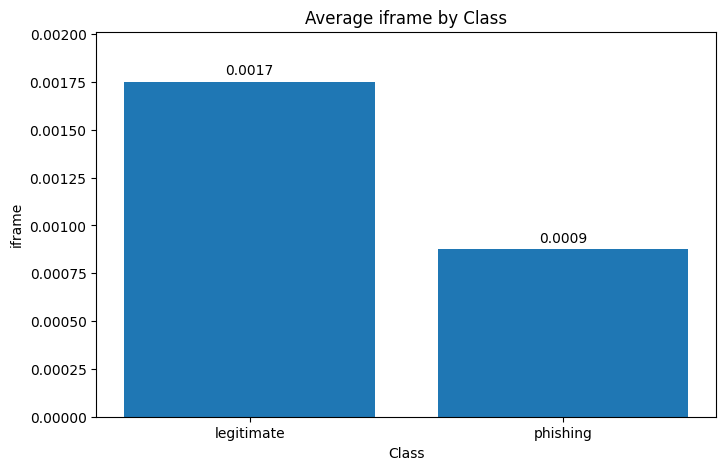

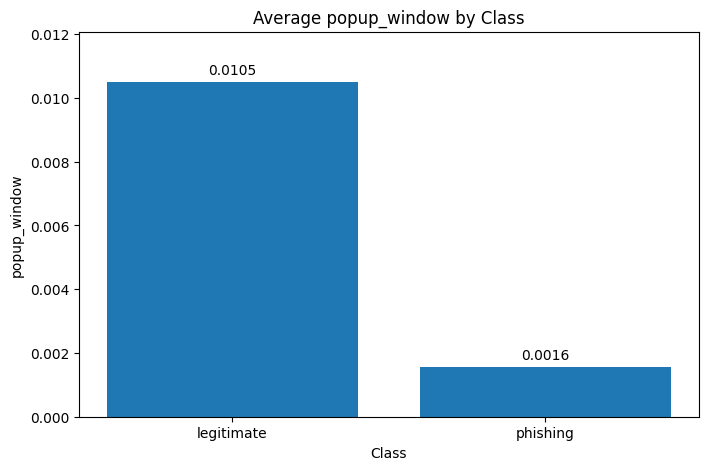

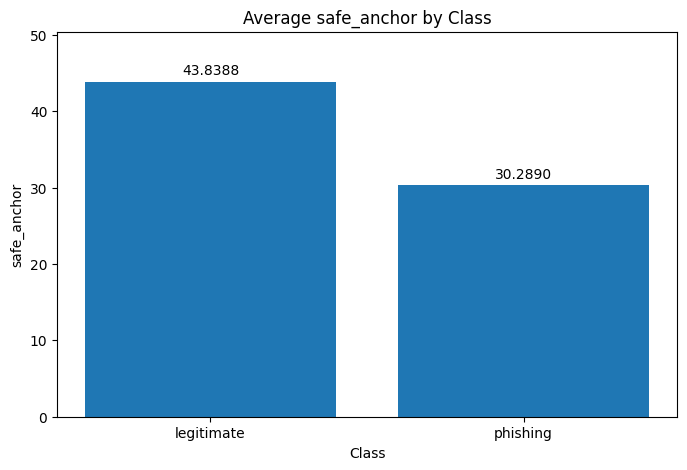

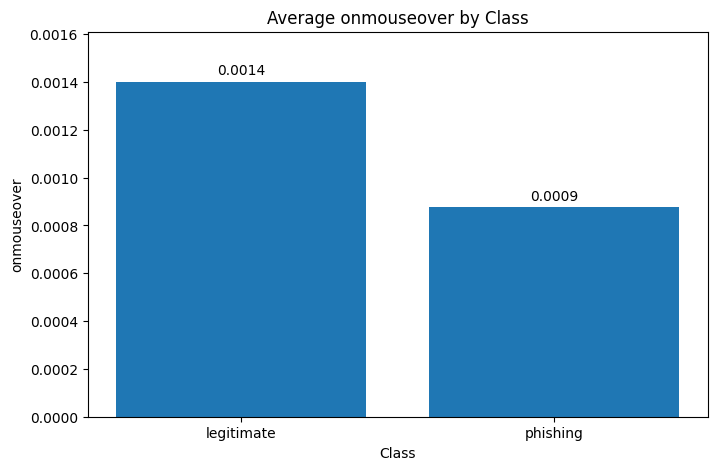

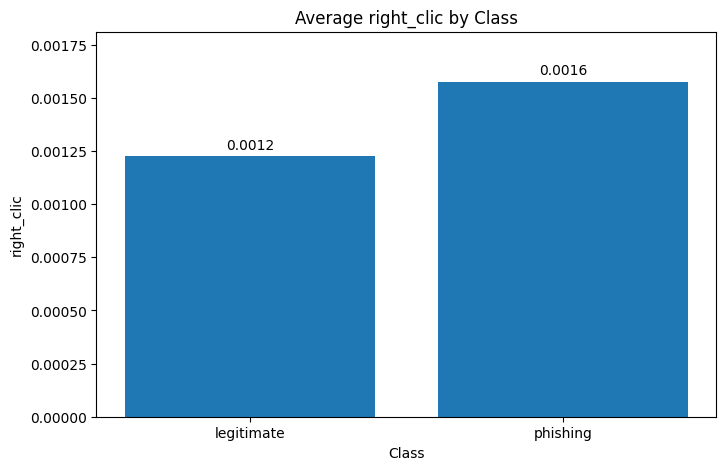

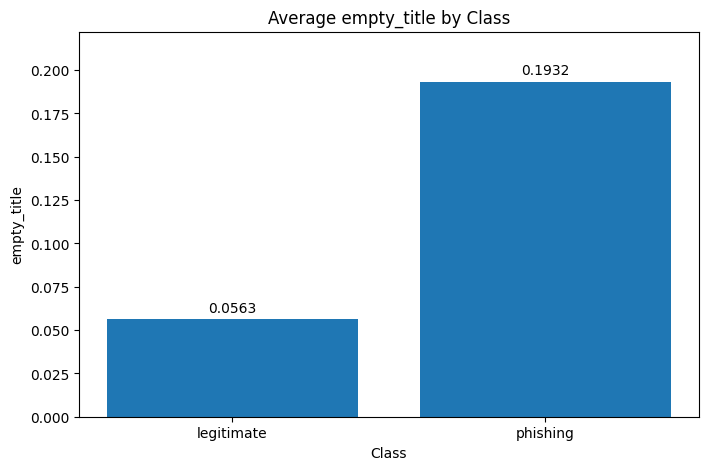

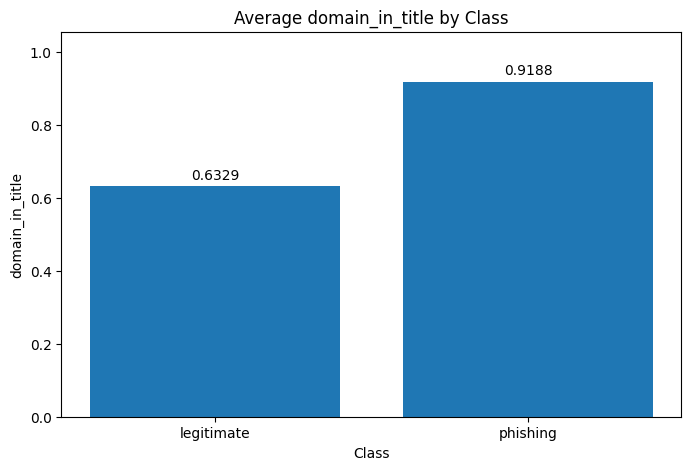

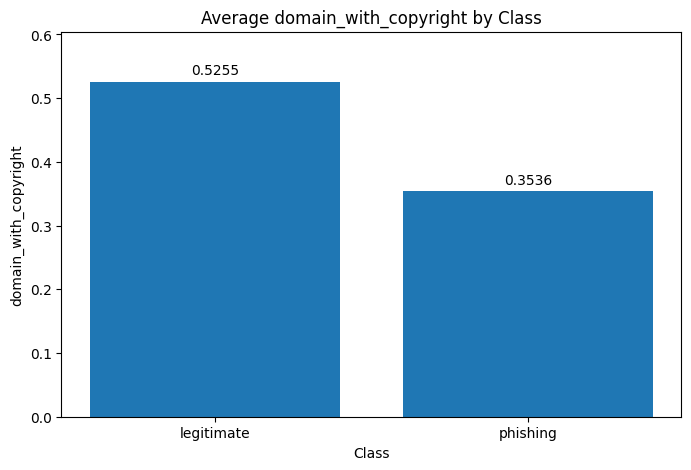

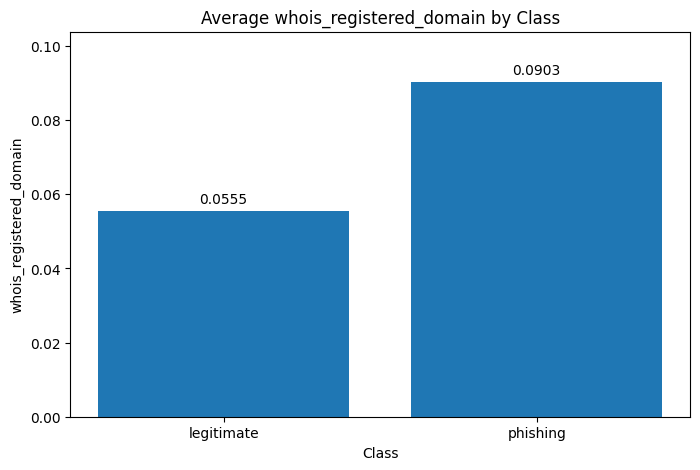

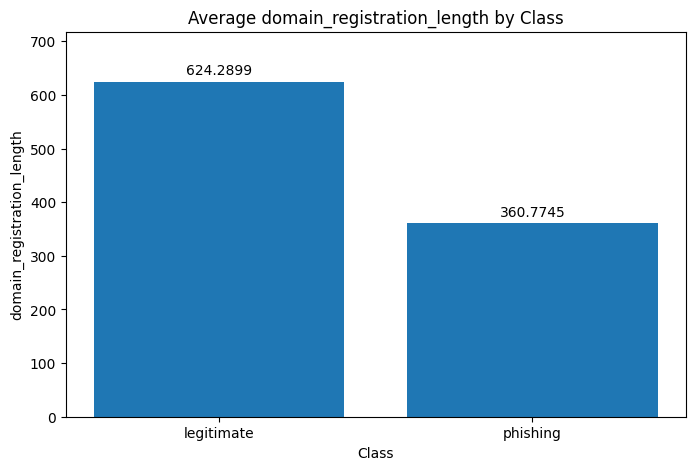

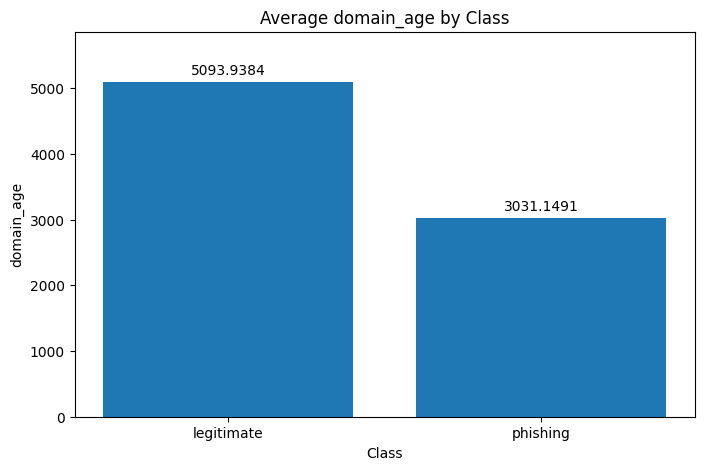

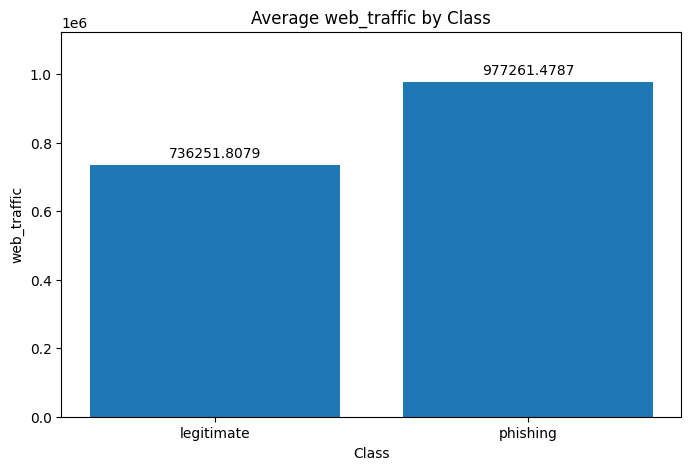

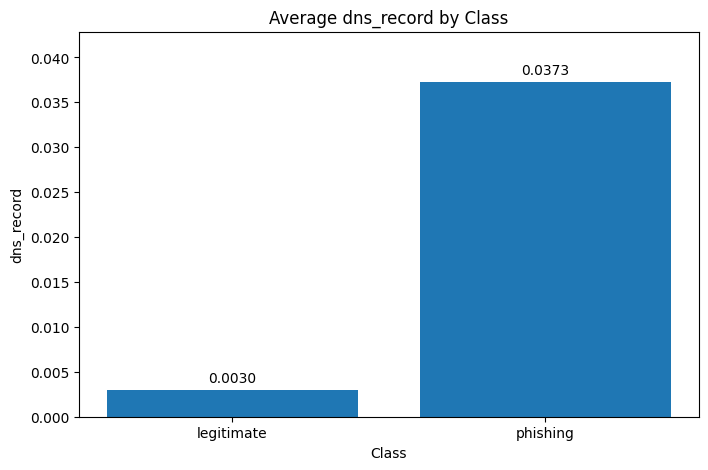

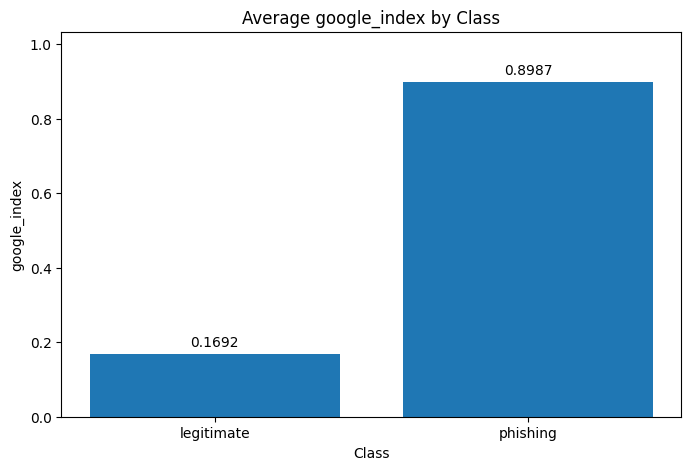

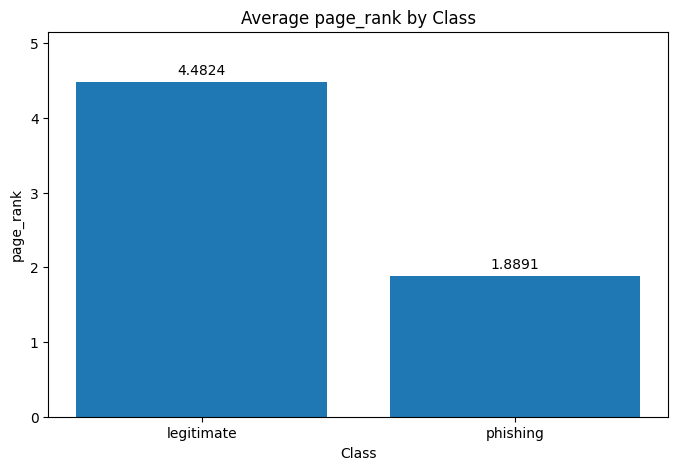

In [ ]:
numeric_columns = dataset_phishing.select_dtypes(include=[np.number]).columns.to_list()

for column in numeric_columns:
    fig, ax = plt.subplots(figsize=(8, 5))

    means = dataset_phishing.groupby('status')[column].mean()
    bars = ax.bar(means.index.astype(str), means.values)

    ax.set_xlabel('Class')
    ax.set_ylabel(column)
    ax.set_title(f'Average {column} by Class')
    ax.set_ylim(0, max(means.values) * 1.15)

    # Add numerical labels on bars
    ax.bar_label(bars, fmt='%.4f', padding=3)

    plt.show()



There is a significant difference in average values of each feature for phishing and legitimate URLs. For instance, phishing URLs on average have a much higher length_url value (approxiamtely 75) compared to legitimate URLs (approximately 47). Another example of a significant difference is that the average page rank of phishing URLs (approximately 1.89) is much lower than that of legitimate URLs (approximately 4.48).

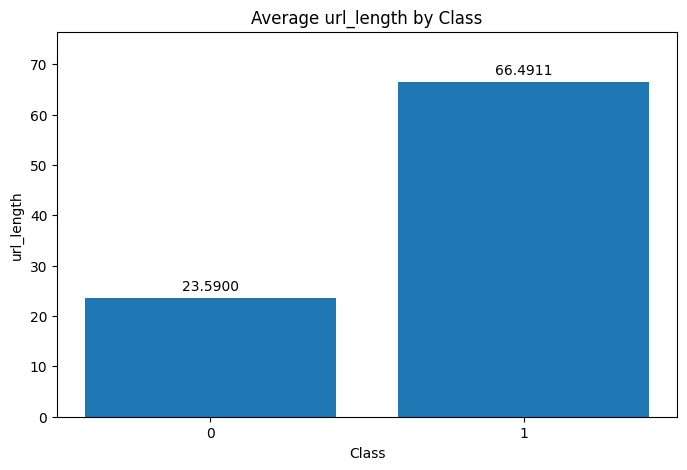

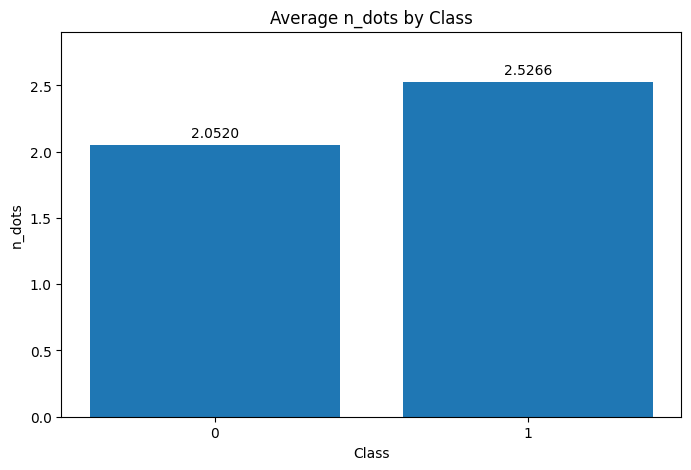

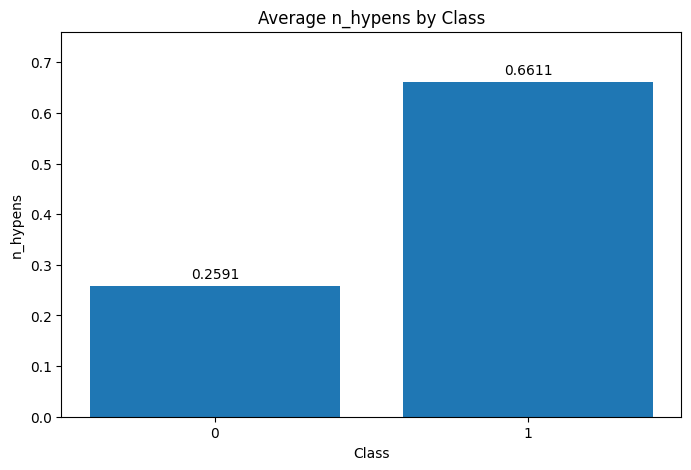

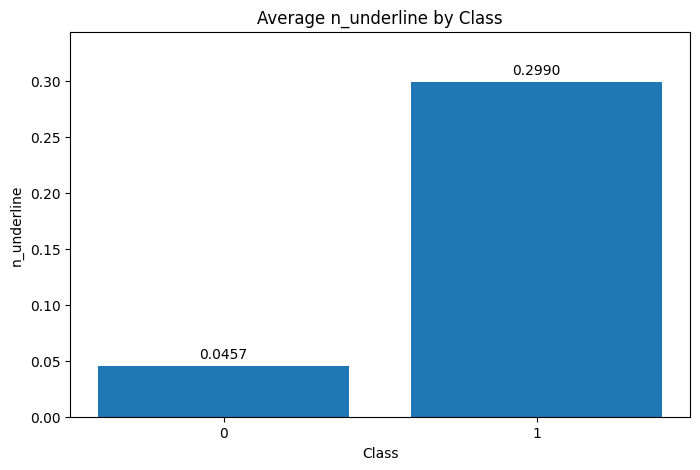

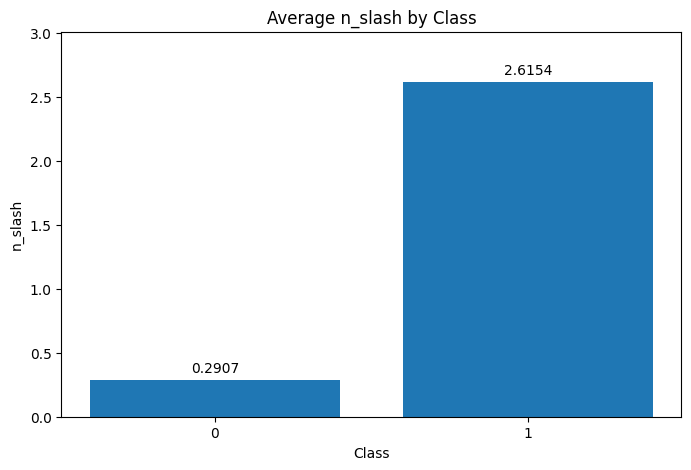

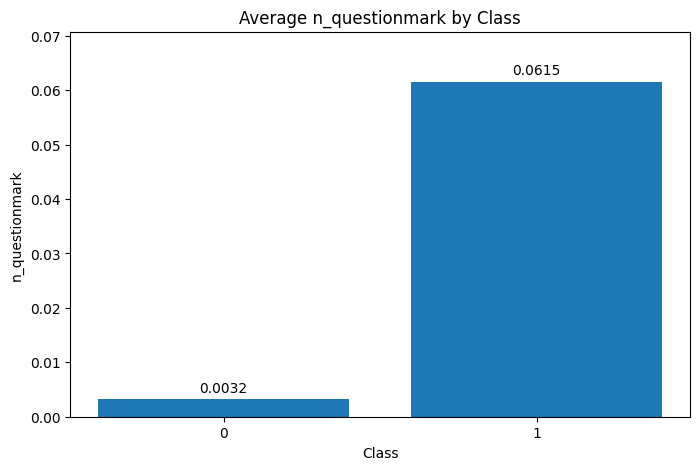

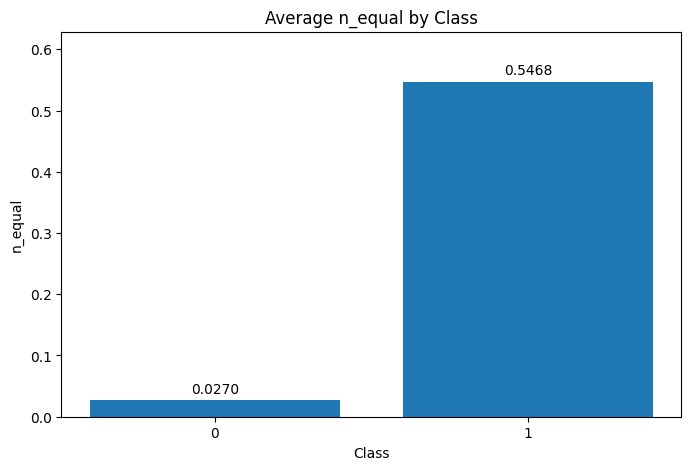

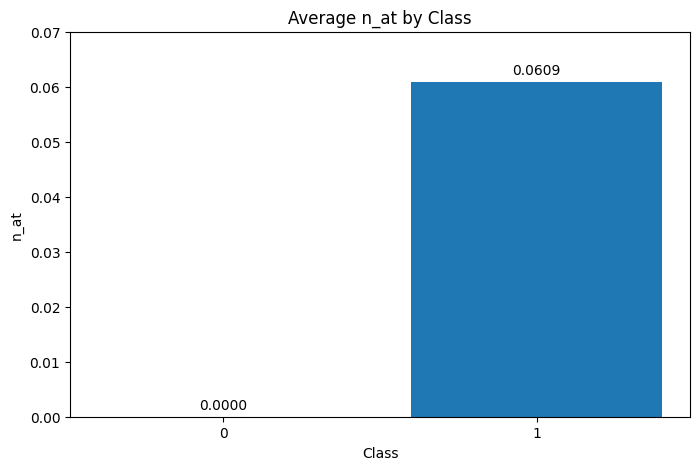

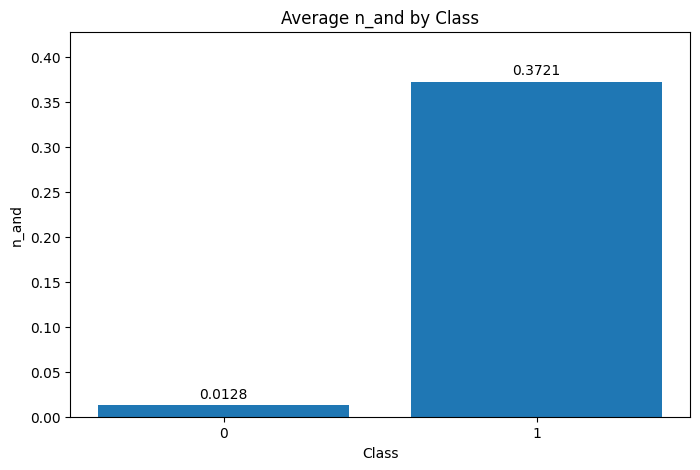

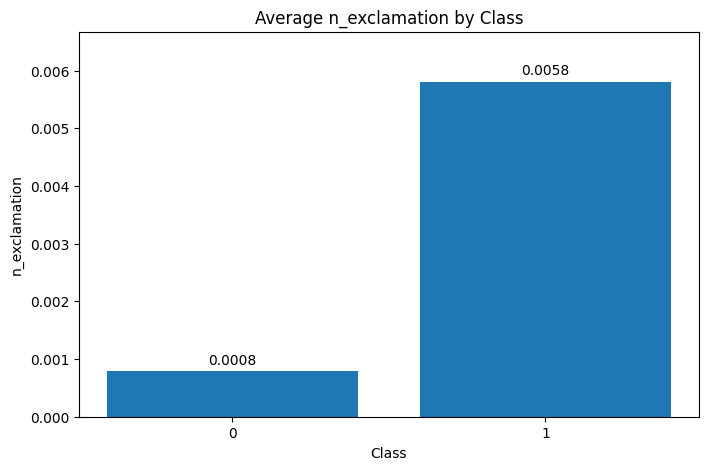

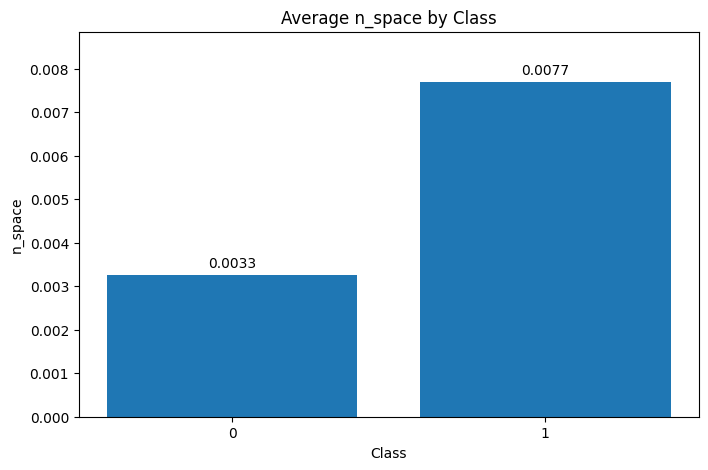

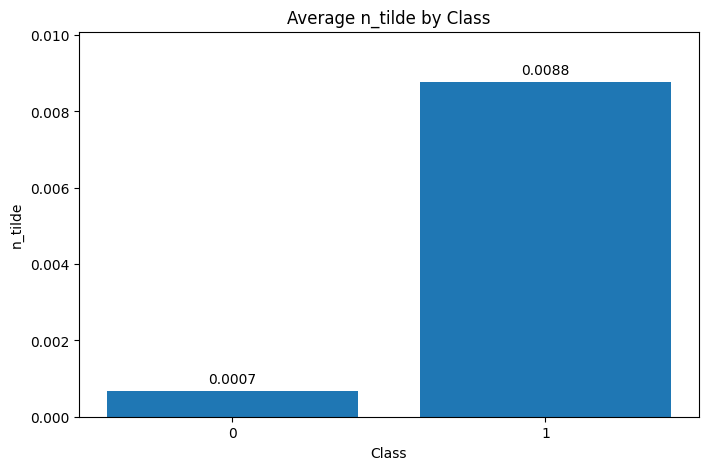

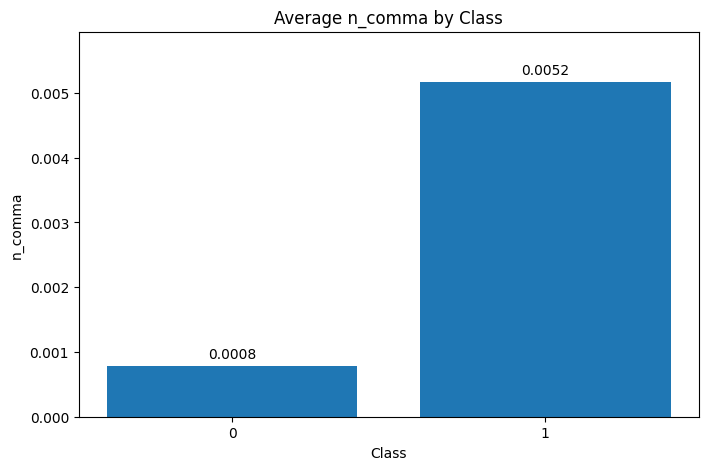

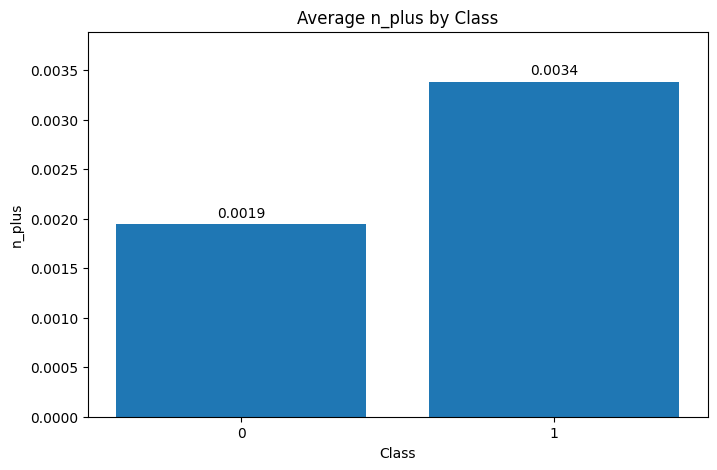

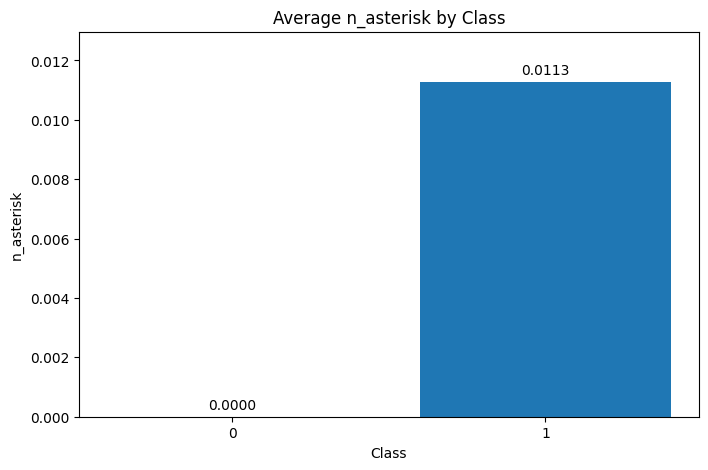

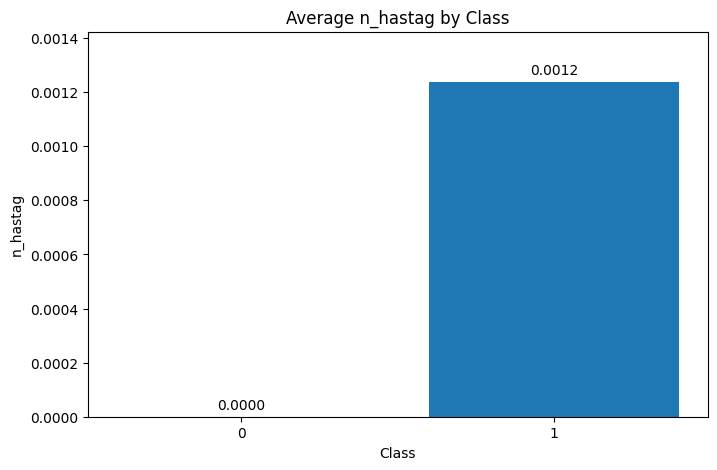

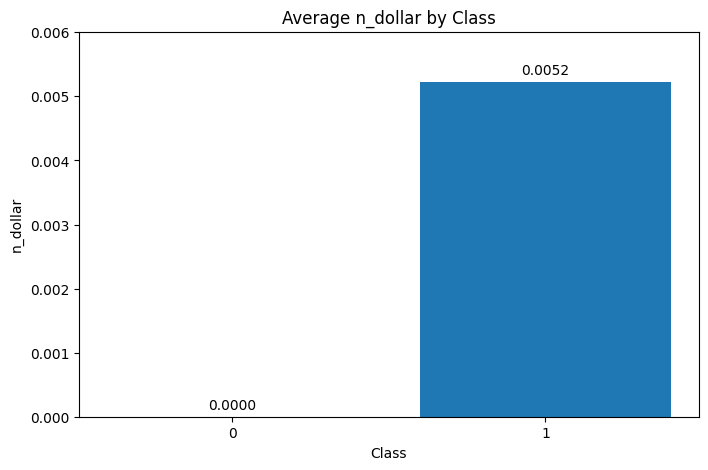

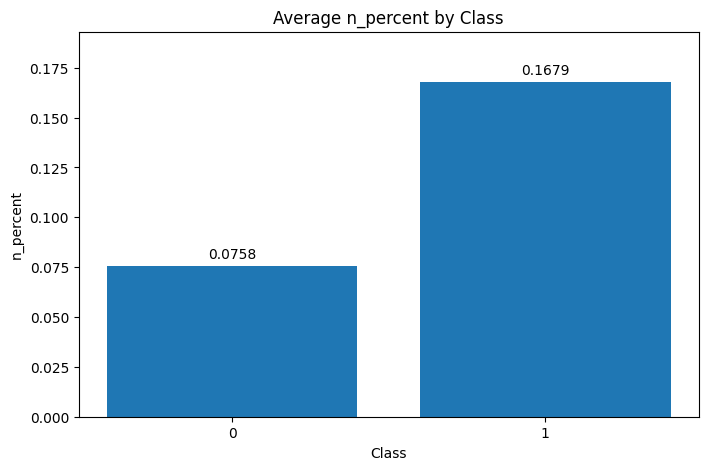

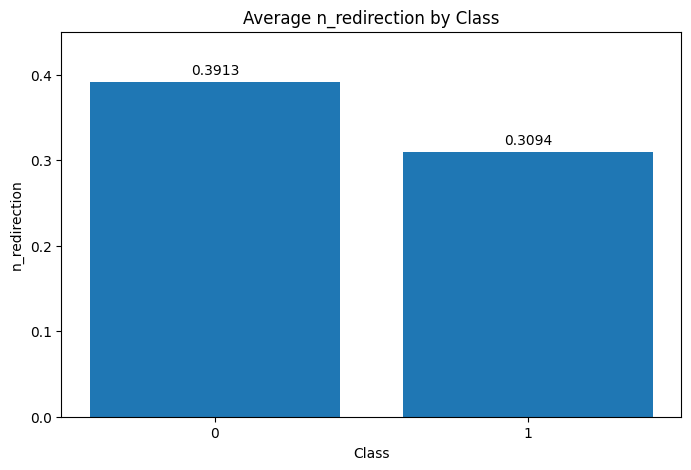

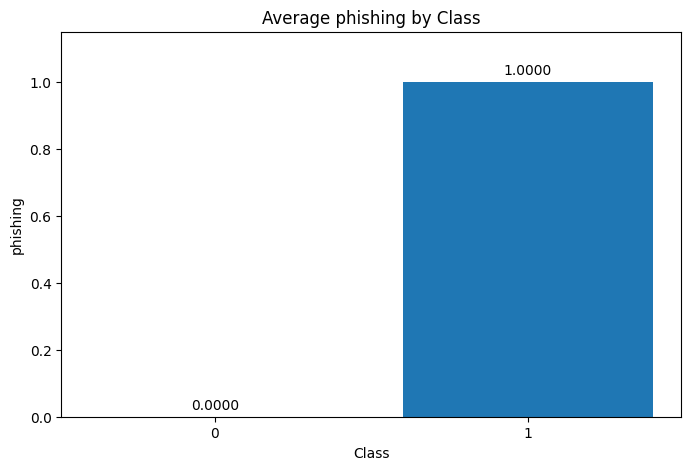

In [ ]:
numeric_columns = web_page_phishing.select_dtypes(include=[np.number]).columns.to_list()

for column in numeric_columns:
    fig, ax = plt.subplots(figsize=(8, 5))

    means = web_page_phishing.groupby('phishing')[column].mean()
    bars = ax.bar(means.index.astype(str), means.values)

    ax.set_xlabel('Class')
    ax.set_ylabel(column)
    ax.set_title(f'Average {column} by Class')
    ax.set_ylim(0, max(means.values) * 1.15)

    # Add numerical labels on bars
    ax.bar_label(bars, fmt='%.4f', padding=3)

    plt.show()

There are significant differences between the average values of the features for phishing (1) and legitimate (0) URLs. For instance, the average length_url value for phishing URLs (approximately 66.5) is much larger than for legitimate URLs (approximately 23.6). Significant differences are also evident for n_hypens (approximately 0.66 for phishing URLs vs approximately 0.26 for legitimate URLs), n_underline (approximately 0.30 for phishing URLs vs approximately 0.05 for legitimate URLs), and n_slash (approximately 2.62 for phishing URLs vs approximately 0.29 for legitimate URLs).



Do LDA on both datasets.

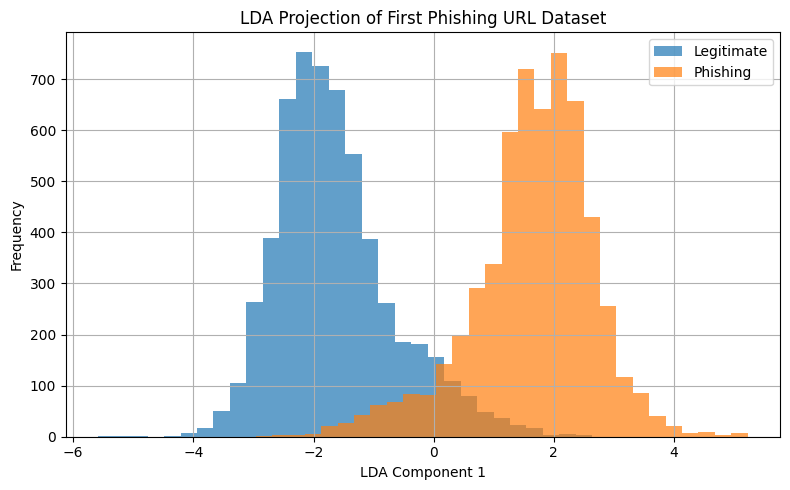

In [ ]:
X = dataset_phishing.drop(['url','status'], axis=1)
y = dataset_phishing['status']
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)
plt.figure(figsize=(8, 5))
plt.hist(X_lda[y == 'legitimate'], label='Legitimate', alpha=0.7, bins=30)
plt.hist(X_lda[y == 'phishing'], label='Phishing', alpha=0.7, bins=30)
plt.xlabel("LDA Component 1")
plt.ylabel("Frequency")
plt.title("LDA Projection of First Phishing URL Dataset")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Based on this, it is clear that the two classes are very linearly separable even though they also have substantial overlap as well.

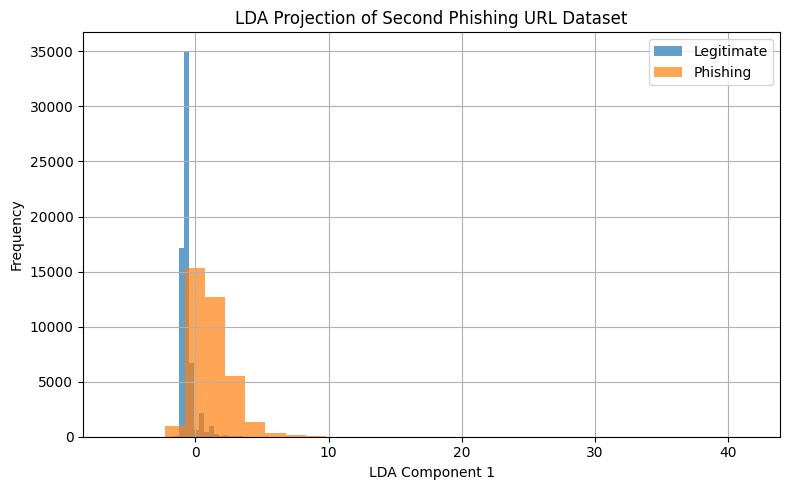

In [ ]:
X = web_page_phishing.drop("phishing", axis=1)
y = web_page_phishing['phishing']
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)
plt.figure(figsize=(8, 5))
plt.hist(X_lda[y == 0], label='Legitimate', alpha=0.7, bins=30)
plt.hist(X_lda[y == 1], label='Phishing', alpha=0.7, bins=30)
plt.xlabel("LDA Component 1")
plt.ylabel("Frequency")
plt.title("LDA Projection of Second Phishing URL Dataset")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

It is evident that there is substantial overlap between the two classes as well as some amount of linear separability.  

For the third dataset, it is important to generate new features using TF-IDF and then do EDA on them.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
X = Phishing_Email['Email Text']
y = Phishing_Email['Email Type']
vectorizer = TfidfVectorizer(stop_words='english',max_features = 1000)
X_tfidf = vectorizer.fit_transform(X)

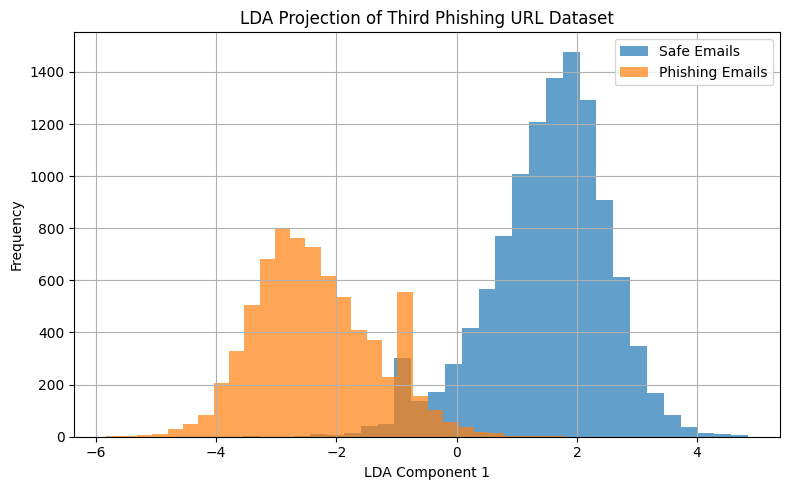

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis(n_components=1)
X_tfidf = X_tfidf.toarray()
X_lda = lda.fit_transform(X_tfidf, y)
plt.figure(figsize=(8, 5))
plt.hist(X_lda[y == "Safe Email"], label='Safe Emails', alpha=0.7, bins=30)
plt.hist(X_lda[y == "Phishing Email"], label='Phishing Emails', alpha=0.7, bins=30)
plt.xlabel("LDA Component 1")
plt.ylabel("Frequency")
plt.title("LDA Projection of Third Phishing URL Dataset")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

While there is some overlap, the classes are clearly  linearly separable when 1000 TF-IDF features are used.